In [1]:
%reload_ext autoreload
%autoreload 2

from utils.custom_sounds import Tone, WhiteNoise, Click, Click_Train
import brian2 as b2
import brian2hears as b2h
from analyze.report import plot_sound
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import fftconvolve, resample
import os
import pysofaconventions as sofa
from scipy.fft import rfft, irfft


2026-02-27 08:17:31,338 [INFO ]  

>>>>> start execution
✅ Using local cochlea package from: /Users/francescodesantis/Documents/repos/sound_localization_model/external/cochlea-1

              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.8.0
 Built: Jul 24 2025 05:26:03

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.




How to cite *cochlea*:

Rudnicki M. and Hemmert W. (2009—). Cochlea: inner ear models in
Python.  https://github.com/mrkrd/cochlea/

@Misc{Rudnicki2009-Cochlea,
  author       = {Rudnicki, M. and Hemmert, W.},
  title        = {Cochlea: inner ear models in Python},
  year         = {2009--},
  howpublished = {https://github.com/mrkrd/cochlea},
  url          = {https://github.com/mrkrd/cochlea},
}



(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'tone_0.5kHz_56dB'}, xlabel='Time (ms)', ylabel='Amplitude'>)

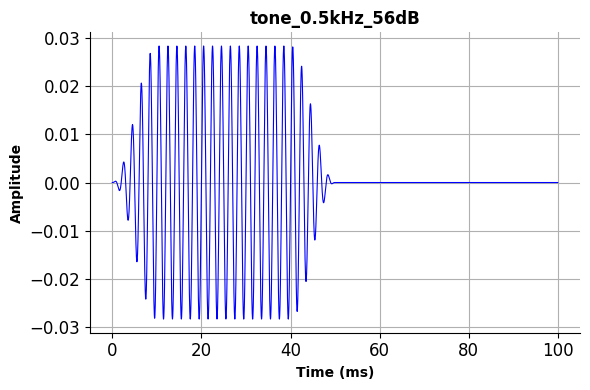

In [2]:
plot_sound(Tone(0.5 * b2.kHz, duration=50 * b2.ms, level=60 * b2h.dB, ramp_ms=10, offset_silence_duration= 50 * b2.ms))

(<Figure size 1000x200 with 1 Axes>,
 <Axes: title={'center': 'tone_0.5kHz_60dB'}, xlabel='Time (ms)', ylabel='Amplitude'>)

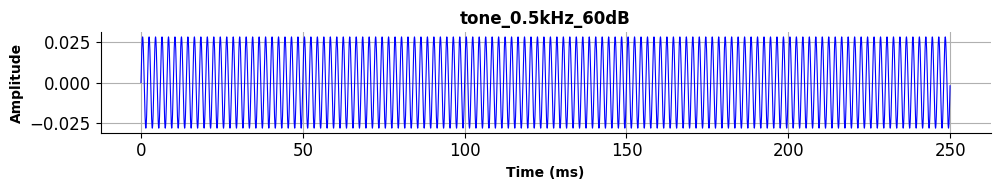

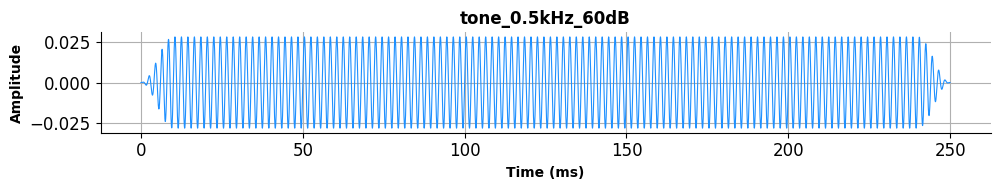

In [3]:
TIME_SIMULATION = 250
level = 60 * b2h.dB
sound = Tone(0.5 * b2.kHz, TIME_SIMULATION * b2.ms, level, ramp_ms=0, offset_silence_duration=0 * b2.ms)
plot_sound(sound, figsize=(10, 2))
gsound = Tone(0.5 * b2.kHz, TIME_SIMULATION * b2.ms, level, ramp_ms=10, offset_silence_duration=0 * b2.ms)
plot_sound(gsound, color='dodgerblue', figsize=(10, 2))

# sound_array = gsound.__array__()
# fig, ax = plt.subplots(1, figsize=(20,4))
# ax.plot(sound_array)

In [3]:
print(gsound.sound.level)
#check
sound_array = gsound.sound.__array__()
# p_peak = np.max(sound_array)
# p_rms = p_peak/np.sqrt(2)
# ms_dB = 20.0 * np.log10(p_rms / 2e-5)
np.mean(sound_array**2)
rms_value = np.sqrt(np.mean(sound_array**2))
ms_dB = 20.0*np.log10(rms_value/2e-5)
print(f"RMS dB SPL: {ms_dB}")

69.77682034686515*dB
RMS dB SPL: 69.77682034686515


In [15]:
HRTF_DIR: str = "../data/SOFA/RIEC/"

files = sorted(
    f for f in os.listdir(HRTF_DIR)
    if f.lower().endswith(".sofa")
)

sofa_path = files[1]
print(sofa_path)
sofa_file = sofa.SOFAFile(str(HRTF_DIR + sofa_path), "r")  # SOFAFile expects a string path
print(sofa_file.getSourcePositionInfo())
ir = sofa_file.getDataIR()                 # shape (M, R, N)
positions = sofa_file.getSourcePositionValues()  # shape (M, C)
az = positions[:, 0]
el = positions[:, 1]
print("az angles tested:\n", np.unique(az))
print("el angles tested:\n", np.unique(el))
ff_az = az[el == 0]
print("all az angles when el = 0°:")
print(ff_az)
print("diff:", np.diff(ff_az))
print("distance: ", positions[:,2][0], "meters")


RIEC_hrir_subject_002.sofa
('degree, degree, metre', 'spherical')
az angles tested:
 [  0.   5.  10.  15.  20.  25.  30.  35.  40.  45.  50.  55.  60.  65.
  70.  75.  80.  85.  90.  95. 100. 105. 110. 115. 120. 125. 130. 135.
 140. 145. 150. 155. 160. 165. 170. 175. 180. 185. 190. 195. 200. 205.
 210. 215. 220. 225. 230. 235. 240. 245. 250. 255. 260. 265. 270. 275.
 280. 285. 290. 295. 300. 305. 310. 315. 320. 325. 330. 335. 340. 345.
 350. 355.]
el angles tested:
 [-30. -20. -10.   0.  10.  20.  30.  40.  50.  60.  70.  80.  90.]
all az angles when el = 0°:
[  0.   5.  10.  15.  20.  25.  30.  35.  40.  45.  50.  55.  60.  65.
  70.  75.  80.  85.  90.  95. 100. 105. 110. 115. 120. 125. 130. 135.
 140. 145. 150. 155. 160. 165. 170. 175. 180. 185. 190. 195. 200. 205.
 210. 215. 220. 225. 230. 235. 240. 245. 250. 255. 260. 265. 270. 275.
 280. 285. 290. 295. 300. 305. 310. 315. 320. 325. 330. 335. 340. 345.
 350. 355.]
diff: [5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 

In [16]:
sofa_fs = float(np.array(sofa_file.getSamplingRate()).ravel()[0])
print(sofa_fs)
sound_fs = float(sound.sound.samplerate)
print(sound_fs)

48000.0
44100.0


In [17]:
plt.rcParams["axes.grid"] = True
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.titleweight']= 'bold'
plt.rcParams['axes.spines.top']= False
plt.rcParams['axes.spines.right']= False
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12   # Size of x-axis tick labels
plt.rcParams['ytick.labelsize'] = 12   # Size of y-axis tick labels
plt.rcParams['legend.fontsize'] = 10   # Size of the legend text
# Make axis labels bold
plt.rcParams['axes.labelweight'] = 'bold'  # Makes x and y axis labels bold

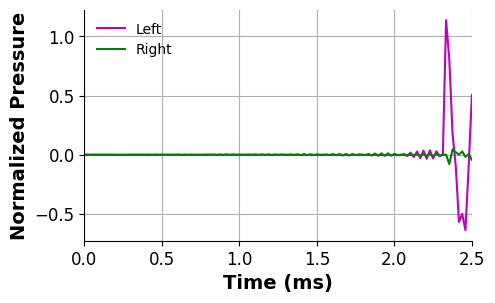

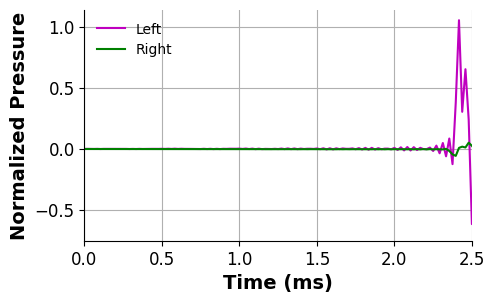

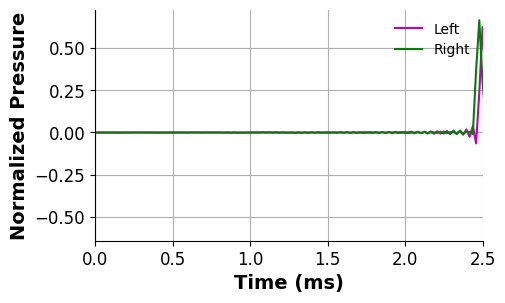

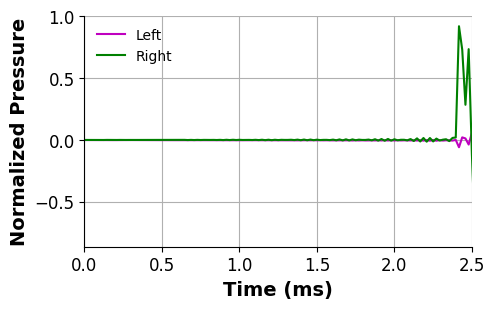

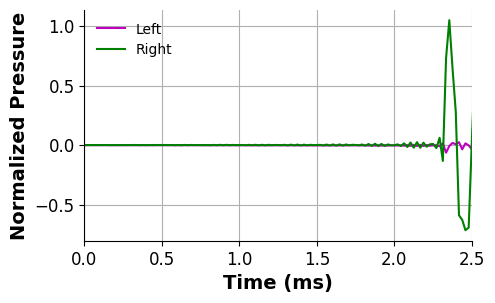

In [18]:
from utils.cochlea_utils import ANGLE_TO_SOFA

times = np.arange(ir.shape[2]) / sofa_fs * 1000  # in ms
for i, a in enumerate([-90, -45, 0, 45, 90]):
    az_converted = ANGLE_TO_SOFA[a]
    diff_az = az - az_converted
    diff_el = el - 0
    dist = np.sqrt(diff_az**2 + diff_el**2)
    m_idx = int(np.argmin(dist))
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.plot(times, ir[m_idx, 0, :], color='m', label='Left')
    ax.plot(times, ir[m_idx, 1, :], color='g', label='Right')
    #ax.set_title(f'HRIR at azimuth {a}° and elevation 0°')
    ax.set_ylabel('Normalized Pressure')
    ax.set_xlabel('Time (ms)')
    ax.set_xlim([0,2.5])
    ax.legend(frameon=False)
    plt.show()

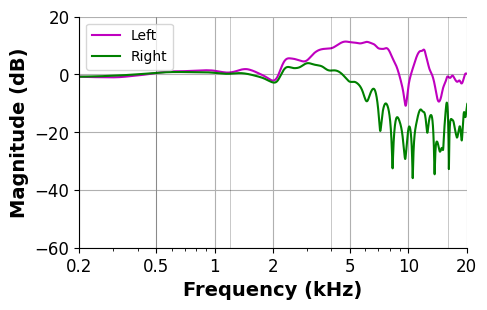

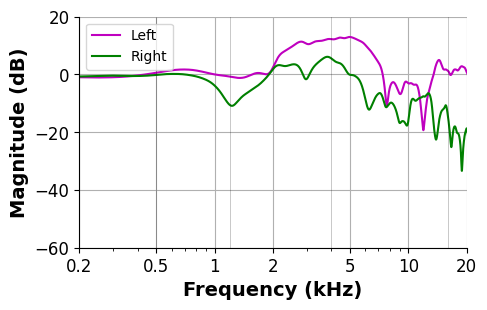

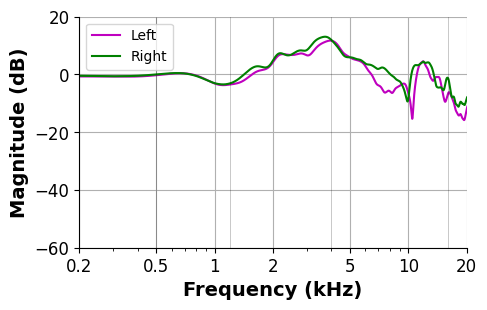

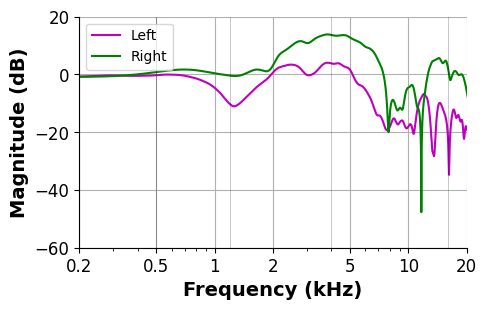

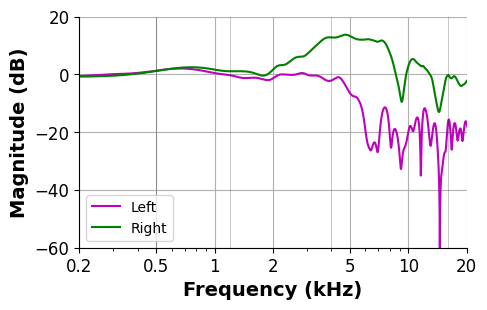

In [19]:
for i, a in enumerate([-90, -45, 0, 45, 90]):
    az_converted = ANGLE_TO_SOFA[a]
    diff_az = az - az_converted
    diff_el = el - 0
    dist = np.sqrt(diff_az**2 + diff_el**2)
    m_idx = int(np.argmin(dist))
    left_ir = ir[m_idx, 0, :]
    right_ir = ir[m_idx, 1, :]

    #1. Resample HRIRs if needed

    if sound_fs != sofa_fs:
        N_old = left_ir.shape[0]
        N_new = int(round(N_old * (sound_fs / sofa_fs)))

        left_ir  = resample(left_ir,  N_new)
        right_ir = resample(right_ir, N_new)

    #2. Zero-pad
    x = gsound.sound.flatten()
    times = np.arange(len(x)) / sound_fs * 1000  # in ms
    N = len(x)

    ir_len = max(len(left_ir), len(right_ir))

    # nmax = next power of 2 >= (signal + ir_length)
    nmax = max(N + ir_len, ir_len)
    nmax = 2**int(np.ceil(np.log2(nmax)))

    Lpad = np.hstack([left_ir,  np.zeros(nmax - len(left_ir))])
    Rpad = np.hstack([right_ir, np.zeros(nmax - len(right_ir))])

    xpad = np.hstack([np.zeros(ir_len), x, np.zeros(nmax - ir_len - N)])

    times = np.arange(Lpad.shape[0]) / sound_fs * 1000  # in ms

    #3. FFT
    L_fft = rfft(Lpad)
    R_fft = rfft(Rpad)
    X_fft = rfft(xpad)

    # IMPORTANT: frequency axis must match nmax!
    freqs = np.fft.rfftfreq(nmax, d=1/sound_fs)

    # --- Convert to magnitude in dB ---
    eps = 1e-12
    L_mag = 20 * np.log10(np.abs(L_fft) + eps)
    R_mag = 20 * np.log10(np.abs(R_fft) + eps)
    X_mag = 20 * np.log10(np.abs(X_fft) + eps)

    # --- Plot ---
    fig, ax = plt.subplots(1, figsize=(5, 3))
    #ax.set_title(f'HRTF Magnitude at azimuth {a}° and elevation 0°')
    ax.semilogx(freqs, L_mag, color='m', label="Left")
    ax.semilogx(freqs, R_mag, color='g', label="Right")
    ax.set_ylabel("Magnitude (dB)")
    ax.legend()
    # --- Custom log-spaced ticks in Hz ---
    xticks_hz = np.array([0.2, 0.5, 1, 2, 5, 10, 20]) * 1000  # kHz → Hz
    for v in [200, 500, 1200, 4000, 16000]:
        ax.axvline(v, color='k', linewidth=0.5, alpha=0.3)

    ax.set_xscale('log')              # explicit, even if semilogx already does it
    ax.set_xticks(xticks_hz)
    ax.set_xticklabels(['0.2', '0.5', '1', '2', '5', '10', '20'])

    ax.set_xlabel("Frequency (kHz)")
    ax.set_xlim(200, 20000)
    ax.set_ylim(-60, 20)

WARNING    /var/folders/ll/11knr8bs6_nbxy20yw3f5kfh0000gn/T/ipykernel_49682/97674561.py:114: UserWarning:Attempt to set non-positive xlim on a log-scaled axis will be ignored.
 [py.warnings]


len before resample: 512
len after resample: 470
Left ear sound level (dB SPL): 69.51830415725426*dB
Right ear sound level (dB SPL): 69.78232179060319*dB


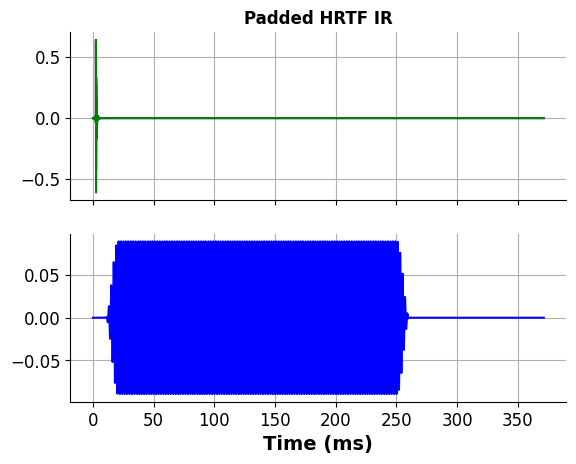

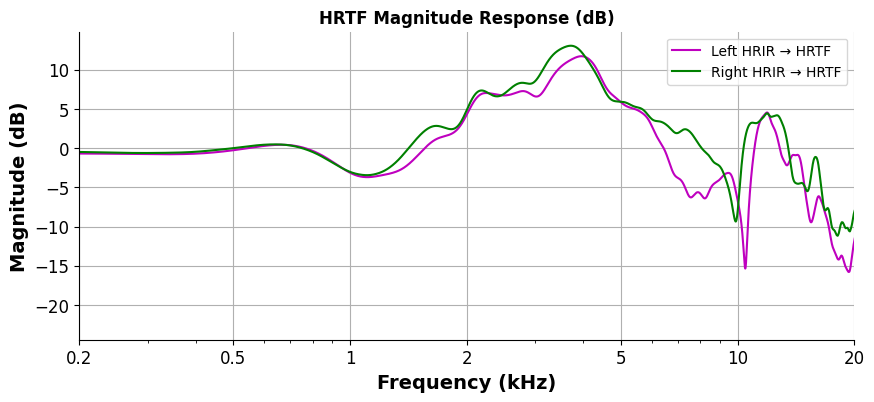

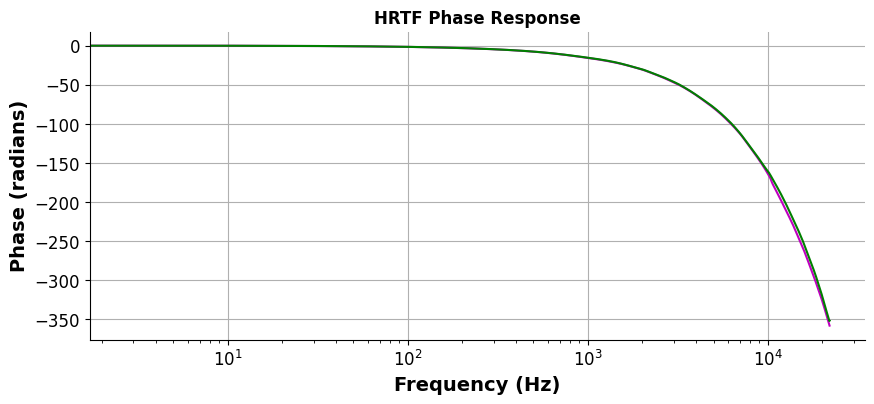

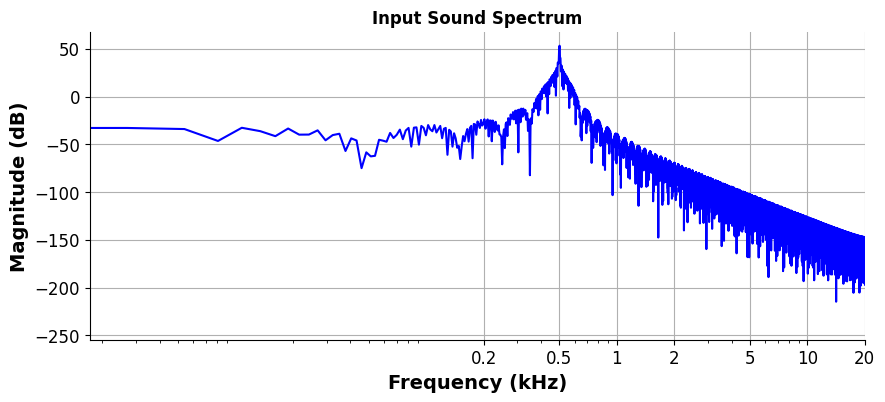

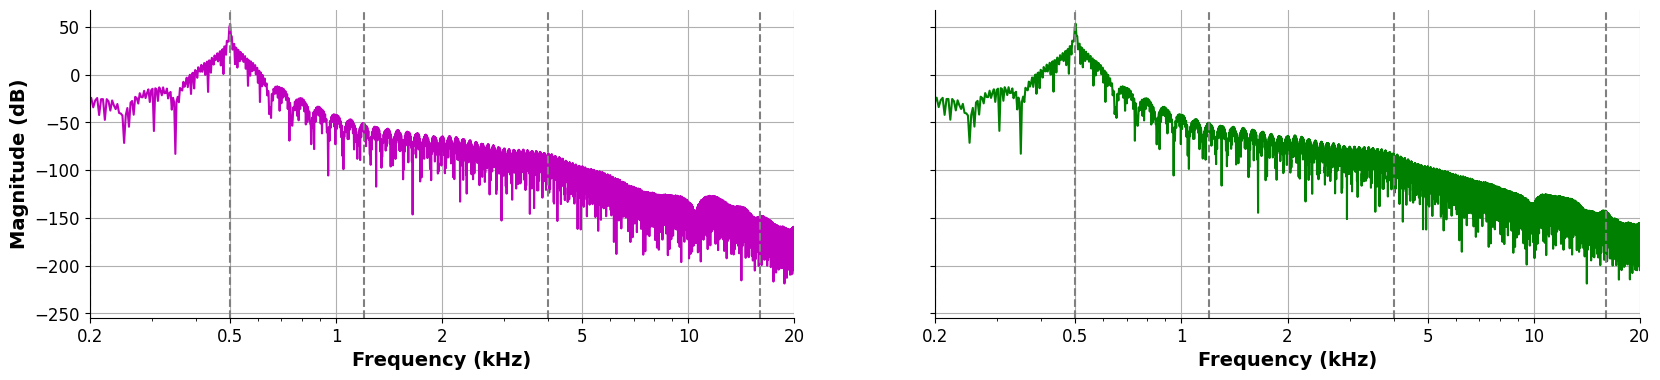

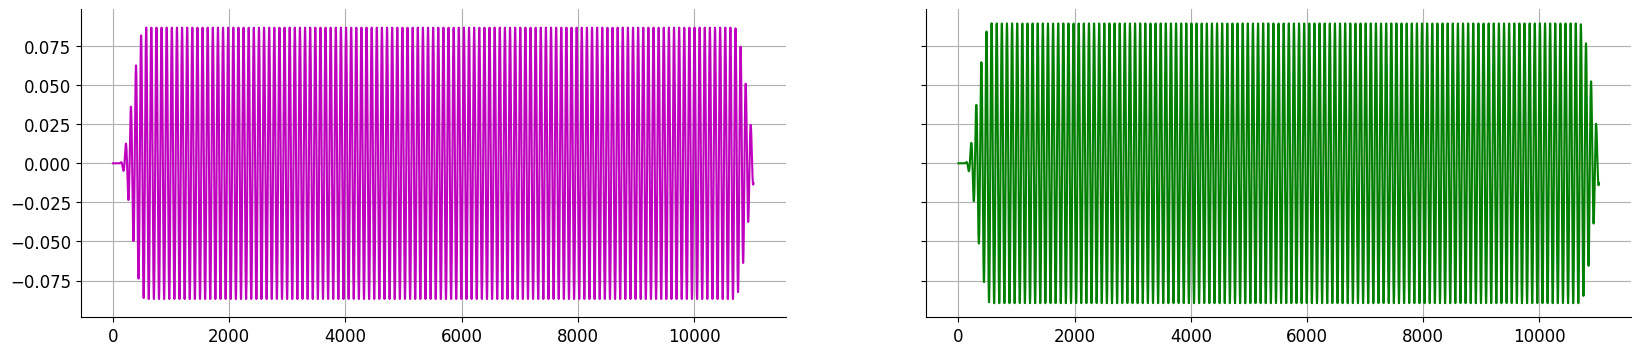

In [9]:
az_angle = 0
az_converted = ANGLE_TO_SOFA[az_angle]
diff_az = az - az_converted
diff_el = el - 0
dist = np.sqrt(diff_az**2 + diff_el**2)
m_idx = int(np.argmin(dist))
left_ir = ir[m_idx, 0, :]
right_ir = ir[m_idx, 1, :]

#1. Resample HRIRs
print("len before resample:", len(left_ir))
if sound_fs != sofa_fs:
    # Compute new length after resampling
    N_old = left_ir.shape[0]
    N_new = int(round(N_old * (sound_fs / sofa_fs)))
    left_ir  = resample(left_ir,  N_new)
    right_ir = resample(right_ir, N_new)
print("len after resample:", len(left_ir))

#2. Zero-pad
x = gsound.sound.flatten()
times = np.arange(len(x)) / sound_fs * 1000  # in ms
N = len(x)
ir_len = max(len(left_ir), len(right_ir))
# nmax = next power of 2 >= (signal + ir_length)
nmax = max(N + ir_len, ir_len)
nmax = 2**int(np.ceil(np.log2(nmax)))
# Zero-pad HRIRs to nmax
Lpad = np.hstack([left_ir,  np.zeros(nmax - len(left_ir))])
Rpad = np.hstack([right_ir, np.zeros(nmax - len(right_ir))])
xpad = np.hstack([np.zeros(ir_len), x, np.zeros(nmax - ir_len - N)])
times = np.arange(Lpad.shape[0]) / sound_fs * 1000  # in ms

#3. FFT

L_fft = rfft(Lpad)
R_fft = rfft(Rpad)
X_fft = rfft(xpad)
# IMPORTANT: frequency axis must match nmax!
freqs = np.fft.rfftfreq(nmax, d=1/sound_fs)
# --- Convert to magnitude in dB ---
eps = 1e-12
L_mag = 20 * np.log10(np.abs(L_fft) + eps)
R_mag = 20 * np.log10(np.abs(R_fft) + eps)
X_mag = 20 * np.log10(np.abs(X_fft) + eps)

#4. Convolution in frequency domain
LX_mag = 20 * np.log10(np.abs(L_fft * X_fft) + eps)
RX_mag = 20 * np.log10(np.abs(R_fft * X_fft) + eps)

#5. Inverse FFT to get output sound
L_out = irfft(L_fft * X_fft).real
R_out = irfft(R_fft * X_fft).real
L_final = L_out[ir_len:ir_len + N]
R_final = R_out[ir_len:ir_len + N]

#6. Level of output sounds
from brian2hears import Sound
Sound(L_final, sound.sound.samplerate).level
Sound(R_final, sound.sound.samplerate).level
print("Left ear sound level (dB SPL):", Sound(L_final, sound.sound.samplerate).level)
print("Right ear sound level (dB SPL):", Sound(R_final, sound.sound.samplerate).level)
#check:
# L_rms = np.sqrt(np.mean(L_final**2))
# R_rms = np.sqrt(np.mean(R_final**2))
# ms_L_dB = 20.0 * np.log10(L_rms / 2e-5)
# ms_R_dB = 20.0 * np.log10(R_rms / 2e-5)
# print("Left ear sound level (dB SPL):", ms_L_dB)
# print("Right ear sound level (dB SPL):", ms_R_dB)

# --- Plot Padding---
fig, ax = plt.subplots(2,1, sharex=True)
ax[0].plot(times, Lpad, color='m')
ax[0].plot(times, Rpad, color='g')
ax[0].set_title(f'Padded HRTF IR')
ax[1].plot(times, xpad, color='b')
ax[1].set_xlabel("Time (ms)")
fig, ax = plt.subplots(1, figsize=(10, 4))
ax.semilogx(freqs, L_mag, color='m', label="Left HRIR → HRTF")
ax.semilogx(freqs, R_mag, color='g', label="Right HRIR → HRTF")
ax.set_ylabel("Magnitude (dB)")
ax.set_title("HRTF Magnitude Response (dB)")
ax.legend()
# --- Custom log-spaced ticks in Hz ---
xticks_hz = np.array([0.2, 0.5, 1, 2, 5, 10, 20]) * 1000  # kHz → Hz
ax.set_xscale('log')              # explicit, even if semilogx already does it
ax.set_xticks(xticks_hz)
ax.set_xticklabels(['0.2', '0.5', '1', '2', '5', '10', '20'])
ax.set_xlabel("Frequency (kHz)")
ax.set_xlim(200, 20000)


# Phase
L_phase = np.unwrap(np.angle(L_fft))
R_phase = np.unwrap(np.angle(R_fft))
fig, ax = plt.subplots(1, figsize=(10, 4))
ax.semilogx(freqs, L_phase, color='m')
ax.semilogx(freqs, R_phase, color='g')
ax.set_ylabel("Phase (radians)")
ax.set_xlabel("Frequency (Hz)")
ax.set_title("HRTF Phase Response")


# --- Plot Input Sound Spectrum---
fig, ax = plt.subplots(1, figsize=(10, 4))
ax.semilogx(freqs, X_mag, color='b')
ax.set_ylabel("Magnitude (dB)")
ax.set_title("Input Sound Spectrum")
xticks_hz = np.array([0.2, 0.5, 1, 2, 5, 10, 20]) * 1000  # kHz → Hz
ax.set_xscale('log')              # explicit, even if semilogx already does it
ax.set_xticks(xticks_hz)
ax.set_xticklabels(['0.2', '0.5', '1', '2', '5', '10', '20'])
ax.set_xlabel("Frequency (kHz)")
ax.set_xlim(0, 20000)

# --- Plot Sounds Spectrum ---
fig, ax = plt.subplots(1,2, figsize=(20, 4), sharey=True)
ax[0].semilogx(freqs, LX_mag, color='m', label="Left HRIR → HRTF")
ax[1].semilogx(freqs, RX_mag, color='g', label="Right HRIR → HRTF")
for v in [200, 500, 1200, 4000, 16000]:
    ax[0].axvline(v, color='gray', linestyle='dashed')
    ax[1].axvline(v, color='gray', linestyle='dashed')
ax[0].set_ylabel("Magnitude (dB)")
xticks_hz = np.array([0.2, 0.5, 1, 2, 5, 10, 20]) * 1000  # kHz → Hz
for a in [0,1]:
    ax[a].set_xscale('log')              # explicit, even if semilogx already does it
    ax[a].set_xticks(xticks_hz)
    ax[a].set_xticklabels(['0.2', '0.5', '1', '2', '5', '10', '20'])
    ax[a].set_xlabel("Frequency (kHz)")
    ax[a].set_xlim(200, 20000)

# --- Plot Sounds Time ---
fig, ax = plt.subplots(1,2, figsize=(20,4), sharey=True)
ax[0].plot(L_final, color='m')
ax[1].plot(R_final, color='g')


['RIEC_hrir_subject_001.sofa', 'RIEC_hrir_subject_002.sofa', 'RIEC_hrir_subject_003.sofa', 'RIEC_hrir_subject_004.sofa', 'RIEC_hrir_subject_005.sofa', 'RIEC_hrir_subject_006.sofa', 'RIEC_hrir_subject_007.sofa', 'RIEC_hrir_subject_008.sofa', 'RIEC_hrir_subject_009.sofa', 'RIEC_hrir_subject_010.sofa']


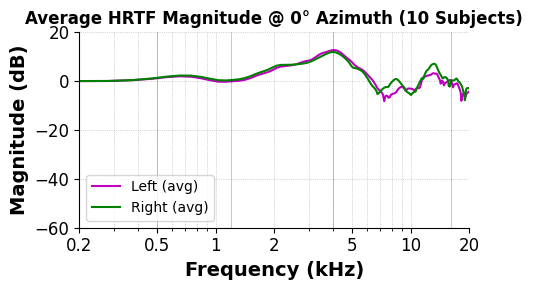

In [10]:
HRTF_DIR: str = "../data/SOFA/RIEC/"

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------
TARGET_AZ = 0          # degrees
TARGET_EL = 0          # degrees
N_SUBJECTS = 10
EPS = 1e-12

# ------------------------------------------------------------
# Collect SOFA files (subjects)
# ------------------------------------------------------------
sofa_files = sorted(
    f for f in os.listdir(HRTF_DIR)
    if f.lower().endswith(".sofa")
)[:N_SUBJECTS]
print(sofa_files)
assert len(sofa_files) >= N_SUBJECTS, "Not enough SOFA files found"

L_mag_all = []
R_mag_all = []

# ------------------------------------------------------------
# Loop over subjects
# ------------------------------------------------------------
for fname in sofa_files:
    sofa_file = sofa.SOFAFile(str(HRTF_DIR + fname), "r")
    
    ir = sofa_file.getDataIR()                    # (M, R, N)
    positions = sofa_file.getSourcePositionValues()
    az = positions[:, 0]
    el = positions[:, 1]

    fs = float(np.array(sofa_file.getSamplingRate()).ravel()[0])

    # --- find closest measurement to (0°, 0°) ---
    az_conv = ANGLE_TO_SOFA[TARGET_AZ]
    dist = np.sqrt((az - az_conv)**2 + (el - TARGET_EL)**2)
    m_idx = int(np.argmin(dist))

    left_ir  = ir[m_idx, 0, :]
    right_ir = ir[m_idx, 1, :]

    # --- FFT ---
    L_fft = rfft(left_ir)
    R_fft = rfft(right_ir)

    # --- magnitude in dB ---
    L_mag = 20 * np.log10(np.abs(L_fft) + EPS)
    R_mag = 20 * np.log10(np.abs(R_fft) + EPS)

    L_mag_all.append(L_mag)
    R_mag_all.append(R_mag)

# ------------------------------------------------------------
# Stack and average across subjects
# ------------------------------------------------------------
L_mag_all = np.vstack(L_mag_all)
R_mag_all = np.vstack(R_mag_all)

L_mag_avg = np.mean(L_mag_all, axis=0)
R_mag_avg = np.mean(R_mag_all, axis=0)

# Frequency axis
n_fft = (L_mag_avg.size - 1) * 2
freqs = np.fft.rfftfreq(n_fft, d=1/fs)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5, 3))

ax.semilogx(freqs, L_mag_avg, color='m', label='Left (avg)')
ax.semilogx(freqs, R_mag_avg, color='g', label='Right (avg)')


ax.set_title(f"Average HRTF Magnitude @ 0° Azimuth ({N_SUBJECTS} Subjects)")
ax.set_ylabel("Magnitude (dB)")
ax.set_xlabel("Frequency (kHz)")
ax.set_xlim(200, 20000)
ax.set_ylim(-60, 20)

    
xticks_hz = np.array([0.2, 0.5, 1, 2, 5, 10, 20]) * 1000
ax.set_xticks(xticks_hz)
ax.set_xticklabels(['0.2', '0.5', '1', '2', '5', '10', '20'])
for v in [200, 500, 1200, 4000, 16000]:
    ax.axvline(v, color='k', linewidth=0.5, alpha=0.3)


ax.legend()
ax.grid(True, which='both', linestyle=':', linewidth=0.5)

plt.tight_layout()
plt.show()

## Different Sounds

In [4]:
TIME_SIMULATION = 250
level = 60 * b2h.dB

inputs = [
    Tone(0.5 * b2.kHz, TIME_SIMULATION * b2.ms, level, ramp_ms=10, offset_silence_duration=0 * b2.ms),
    Tone(1.2 * b2.kHz, TIME_SIMULATION * b2.ms, level, ramp_ms=10, offset_silence_duration=0 * b2.ms),
    Tone(4 * b2.kHz, TIME_SIMULATION * b2.ms, level, ramp_ms=10, offset_silence_duration=0 * b2.ms),
    Tone(16 * b2.kHz, TIME_SIMULATION * b2.ms, level, ramp_ms=10, offset_silence_duration=0 * b2.ms),
    WhiteNoise(TIME_SIMULATION * b2.ms, level, ramp_ms=10, offset_silence_duration=0 * b2.ms),
]
inputs_2 = [Click(duration= TIME_SIMULATION * b2.ms, click_duration=1, level=level)]

In [5]:
from utils.hrtf_utils import run_hrtf
from simulate.models.BrainstemModel.params import Parameters as params
from utils.anf_utils import ZI_COC_KEY, create_sound_key
import matplotlib.colors as mcolors
from utils.cochlea_utils import ANGLES

p = params()
print(p.cochlea[ZI_COC_KEY]['hrtf_params'])

{'subj_number': 0, 'itd_remove_strategy': 'estimate_from_hrtf'}


2026-02-17 14:07:56,892 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0


(<Figure size 600x400 with 1 Axes>,
 <Axes: xlabel='Time (ms)', ylabel='Amplitude'>)

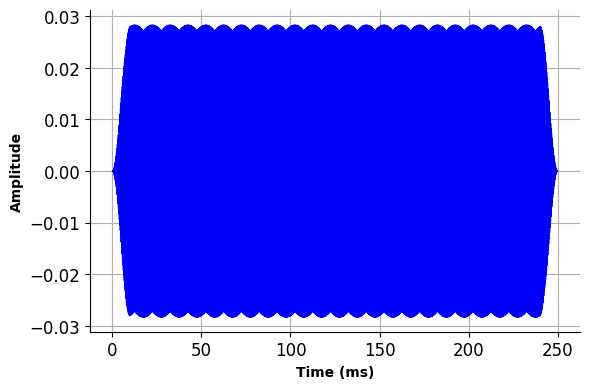

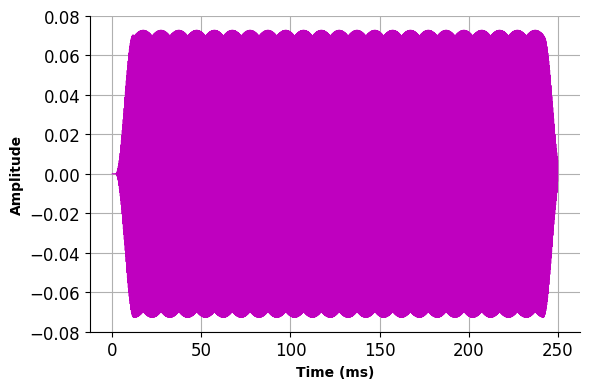

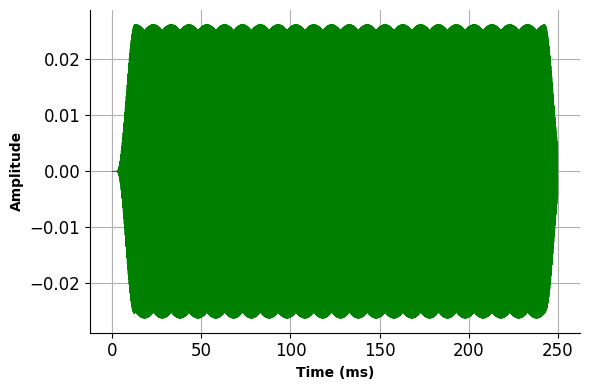

In [ ]:
binaural, g = run_hrtf(inputs[2], -90, p.cochlea[ZI_COC_KEY]['hrtf_params'])
plot_sound(g, ylim=(-0.3, 0.3))
plot_sound(binaural.left, color='m')
plot_sound(binaural.right, color='g')

2026-02-10 15:07:11,905 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2026-02-10 15:07:12,030 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2026-02-10 15:07:12,099 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2026-02-10 15:07:12,111 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2026-02-10 15:07:12,121 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2026-02-10 15:07:12,133 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=1
2026-02-10 15:07:12,160 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=1
2026-02-10 15:07:12,165 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=1
2026-02-10 15:07:12,169 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=1
2026-02-10 15:07:12,315 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=1
2026-02-10 15:07:12,352 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=2
2026-02-10 15:07:12,461 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=2
2026-02-10 15:07:12,535 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=2

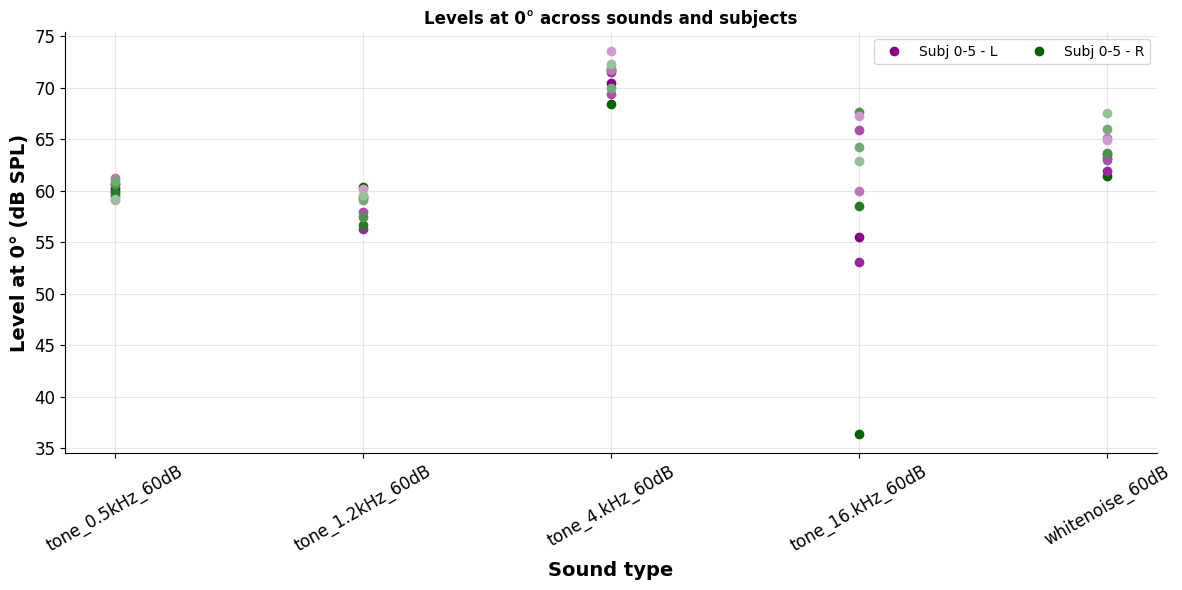

In [33]:
# pick the angle you want to isolate
ANGLE0 = 0
subjects = range(5)
# --- build shades starting from darkmagenta / darkgreen ---
base_magenta = np.array(mcolors.to_rgb("darkmagenta"))
base_green   = np.array(mcolors.to_rgb("darkgreen"))
white        = np.array([1.0, 1.0, 1.0])

# alpha controls how strong the base color is (1 = darkest, 0 = white)
alphas = np.linspace(1.0, 0.4, len(subjects))  # subj 0 darker, subj 5 lighter

magenta_colors = [tuple(white * (1 - a) + base_magenta * a) for a in alphas]
green_colors   = [tuple(white * (1 - a) + base_green   * a) for a in alphas]

plt.figure(figsize=(12, 6))
plt.title(f"Levels at {ANGLE0}° across sounds and subjects")

sound_labels = [create_sound_key(s) for s in inputs]
x = np.arange(len(inputs))

for s_idx, subj in enumerate(subjects):
    p.cochlea[ZI_COC_KEY]['hrtf_params']['subj_number'] = subj

    l_at_0 = []
    r_at_0 = []

    for sound in inputs:
        binaural, g = run_hrtf(sound, ANGLE0, p.cochlea[ZI_COC_KEY]['hrtf_params'])
        l_at_0.append(binaural[:, 0].level)
        r_at_0.append(binaural[:, 1].level)

    # plot for each subject: L solid, R dashed
    plt.plot(
        x, l_at_0, "o", 
        color=magenta_colors[s_idx],
        label=f"Subj 0-{len(subjects)} - L" if s_idx == 0 else None
    )
    plt.plot(
        x, r_at_0, "o",
        color=green_colors[s_idx],
        label=f"Subj 0-{len(subjects)} - R" if s_idx == 0 else None
    )

plt.xticks(x, sound_labels, rotation=30)
plt.xlabel("Sound type")
plt.ylabel("Level at 0° (dB SPL)")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


2026-02-10 15:07:17,300 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2026-02-10 15:07:17,565 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=1
2026-02-10 15:07:17,776 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=2
2026-02-10 15:07:17,908 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=3
2026-02-10 15:07:18,071 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=4


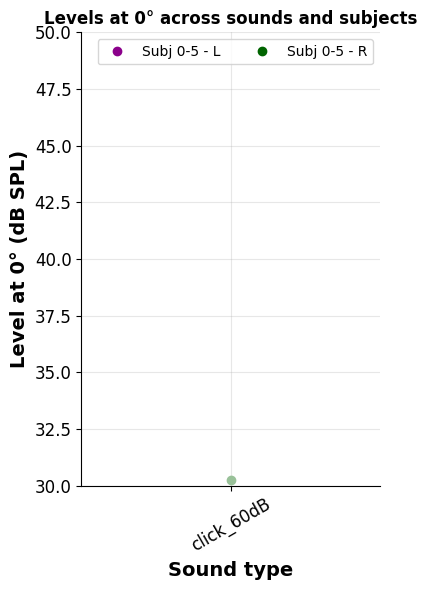

In [34]:
# pick the angle you want to isolate
ANGLE0 = 0
subjects = range(5)
# --- build shades starting from darkmagenta / darkgreen ---
base_magenta = np.array(mcolors.to_rgb("darkmagenta"))
base_green   = np.array(mcolors.to_rgb("darkgreen"))
white        = np.array([1.0, 1.0, 1.0])

# alpha controls how strong the base color is (1 = darkest, 0 = white)
alphas = np.linspace(1.0, 0.4, len(subjects))  # subj 0 darker, subj 5 lighter

magenta_colors = [tuple(white * (1 - a) + base_magenta * a) for a in alphas]
green_colors   = [tuple(white * (1 - a) + base_green   * a) for a in alphas]

plt.figure(figsize=(4, 6))
plt.title(f"Levels at {ANGLE0}° across sounds and subjects")

sound_labels = [create_sound_key(s) for s in inputs_2]
x = np.arange(len(inputs_2))

for s_idx, subj in enumerate(subjects):
    p.cochlea[ZI_COC_KEY]['hrtf_params']['subj_number'] = subj

    l_at_0 = []
    r_at_0 = []

    for sound in inputs_2:
        binaural, g = run_hrtf(sound, ANGLE0, p.cochlea[ZI_COC_KEY]['hrtf_params'])
        l_at_0.append(binaural[:, 0].level)
        r_at_0.append(binaural[:, 1].level)

    # plot for each subject: L solid, R dashed
    plt.plot(
        x, l_at_0, "o", 
        color=magenta_colors[s_idx],
        label=f"Subj 0-{len(subjects)} - L" if s_idx == 0 else None
    )
    plt.plot(
        x, r_at_0, "o",
        color=green_colors[s_idx],
        label=f"Subj 0-{len(subjects)} - R" if s_idx == 0 else None
    )

plt.xticks(x, sound_labels, rotation=30)
plt.xlabel("Sound type")
plt.ylabel("Level at 0° (dB SPL)")
plt.grid(True, alpha=0.3)
plt.ylim(30, 50)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


2026-02-10 15:07:21,669 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2026-02-10 15:07:21,825 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2026-02-10 15:07:21,903 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2026-02-10 15:07:21,965 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2026-02-10 15:07:22,004 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2026-02-10 15:07:22,013 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=1
2026-02-10 15:07:22,021 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=1
2026-02-10 15:07:22,171 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=1
2026-02-10 15:07:22,210 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=1
2026-02-10 15:07:22,260 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=1
2026-02-10 15:07:22,267 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=2
2026-02-10 15:07:22,303 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=2
2026-02-10 15:07:22,325 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=2

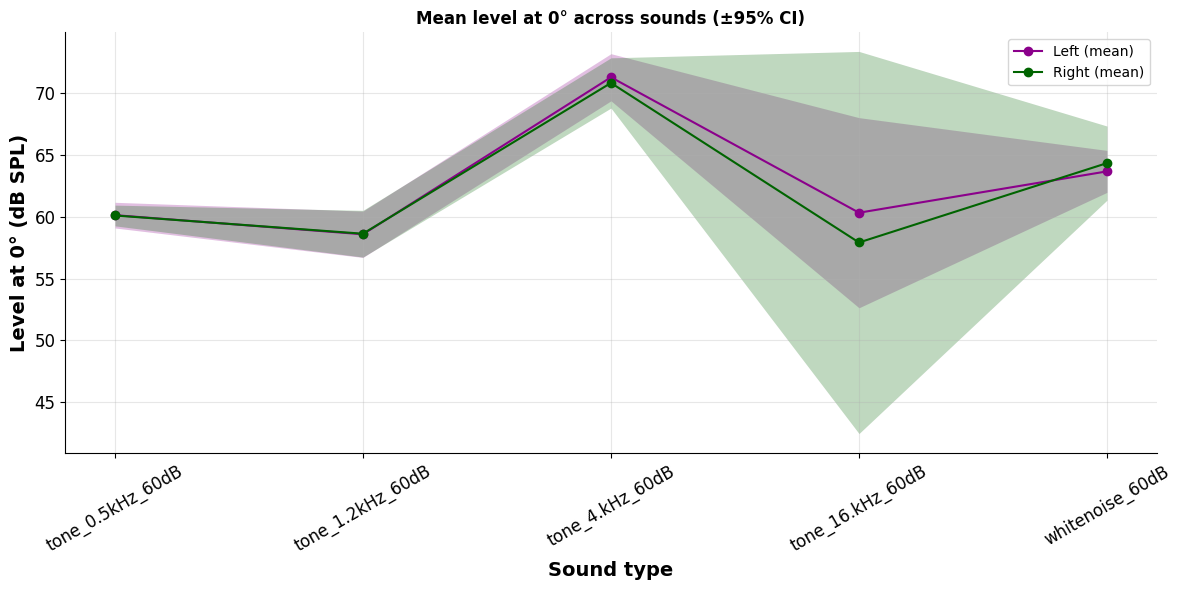

In [35]:
from scipy.stats import t

ANGLE0 = 0

plt.figure(figsize=(12, 6))
plt.title(f"Mean level at {ANGLE0}° across sounds (±95% CI)")

sound_labels = [create_sound_key(s) for s in inputs]
x = np.arange(len(inputs))

# containers: shape = (n_subjects, n_sounds)
L_all = []
R_all = []

for subj in subjects:
    p.cochlea[ZI_COC_KEY]['hrtf_params']['subj_number'] = subj

    l_at_0 = []
    r_at_0 = []

    for sound in inputs:
        binaural, g = run_hrtf(sound, ANGLE0, p.cochlea[ZI_COC_KEY]['hrtf_params'])
        l_at_0.append(binaural[:, 0].level)
        r_at_0.append(binaural[:, 1].level)

    L_all.append(l_at_0)
    R_all.append(r_at_0)

L_all = np.array(L_all)  # (subjects, sounds)
R_all = np.array(R_all)

# --- statistics ---
n = len(subjects)
df = n - 1
tval = t.ppf(0.975, df)  # 95% CI

L_mean = L_all.mean(axis=0)
R_mean = R_all.mean(axis=0)

L_sem = L_all.std(axis=0, ddof=1) / np.sqrt(n)
R_sem = R_all.std(axis=0, ddof=1) / np.sqrt(n)

L_ci = tval * L_sem
R_ci = tval * R_sem

# --- plot ---
plt.plot(x, L_mean, "o-", color="darkmagenta", label="Left (mean)")
plt.plot(x, R_mean, "o-", color="darkgreen", label="Right (mean)")

plt.fill_between(
    x, L_mean - L_ci, L_mean + L_ci,
    color="darkmagenta", alpha=0.25, linewidth=0
)
plt.fill_between(
    x, R_mean - R_ci, R_mean + R_ci,
    color="darkgreen", alpha=0.25, linewidth=0
)

plt.xticks(x, sound_labels, rotation=30)
plt.xlabel("Sound type")
plt.ylabel("Level at 0° (dB SPL)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


2026-02-10 15:07:28,621 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2026-02-10 15:07:28,697 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=1
2026-02-10 15:07:28,837 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=2
2026-02-10 15:07:28,864 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=3
2026-02-10 15:07:28,977 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=4


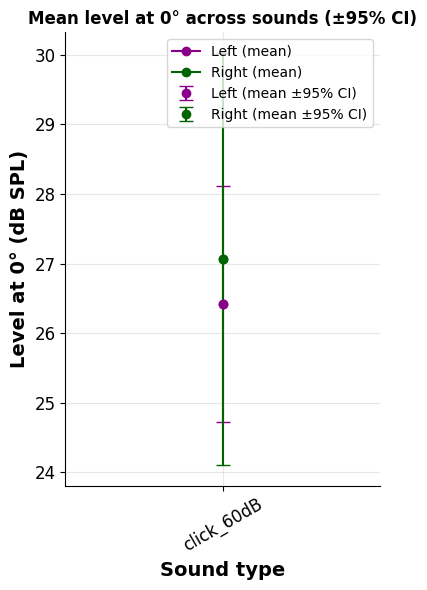

In [36]:
from scipy.stats import t

ANGLE0 = 0

plt.figure(figsize=(4, 6))
plt.title(f"Mean level at {ANGLE0}° across sounds (±95% CI)")

sound_labels = [create_sound_key(s) for s in inputs_2]
x = np.arange(len(inputs_2)) 
# containers: shape = (n_subjects, n_sounds)
L_all = []
R_all = []

for subj in subjects:
    p.cochlea[ZI_COC_KEY]['hrtf_params']['subj_number'] = subj

    l_at_0 = []
    r_at_0 = []

    for sound in inputs_2:
        binaural, g = run_hrtf(sound, ANGLE0, p.cochlea[ZI_COC_KEY]['hrtf_params'])
        l_at_0.append(binaural[:, 0].level)
        r_at_0.append(binaural[:, 1].level)

    L_all.append(l_at_0)
    R_all.append(r_at_0)

L_all = np.array(L_all)  # (subjects, sounds)
R_all = np.array(R_all)

# --- statistics ---
n = len(subjects)
df = n - 1
tval = t.ppf(0.975, df)  # 95% CI

L_mean = L_all.mean(axis=0)
R_mean = R_all.mean(axis=0)

L_sem = L_all.std(axis=0, ddof=1) / np.sqrt(n)
R_sem = R_all.std(axis=0, ddof=1) / np.sqrt(n)

L_ci = tval * L_sem
R_ci = tval * R_sem

# --- plot ---
plt.plot(x, L_mean, "o-", color="darkmagenta", label="Left (mean)")
plt.plot(x, R_mean, "o-", color="darkgreen", label="Right (mean)")

# single sound → use error bars
plt.errorbar(
    x, L_mean, yerr=L_ci,
    fmt="o", color="darkmagenta",
    capsize=5, label="Left (mean ±95% CI)"
)
plt.errorbar(
    x, R_mean, yerr=R_ci,
    fmt="o", color="darkgreen",
    capsize=5, label="Right (mean ±95% CI)"
)


plt.xticks(x, sound_labels, rotation=30)
plt.xlabel("Sound type")
plt.ylabel("Level at 0° (dB SPL)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


2026-02-10 15:08:43,595 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2026-02-10 15:08:43,713 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=0
2026-02-10 15:08:43,917 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=0
2026-02-10 15:08:43,999 [DEBUG]  [run_hrtf] Starting HRTF for angle=-45 subj=0
2026-02-10 15:08:44,010 [DEBUG]  [run_hrtf] Starting HRTF for angle=-30 subj=0
2026-02-10 15:08:44,020 [DEBUG]  [run_hrtf] Starting HRTF for angle=-15 subj=0
2026-02-10 15:08:44,026 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2026-02-10 15:08:44,033 [DEBUG]  [run_hrtf] Starting HRTF for angle=15 subj=0
2026-02-10 15:08:44,051 [DEBUG]  [run_hrtf] Starting HRTF for angle=30 subj=0
2026-02-10 15:08:44,107 [DEBUG]  [run_hrtf] Starting HRTF for angle=45 subj=0
2026-02-10 15:08:44,196 [DEBUG]  [run_hrtf] Starting HRTF for angle=60 subj=0
2026-02-10 15:08:44,279 [DEBUG]  [run_hrtf] Starting HRTF for angle=75 subj=0
2026-02-10 15:08:44,285 [DEBUG]  [run_hrtf] Starting HRTF f

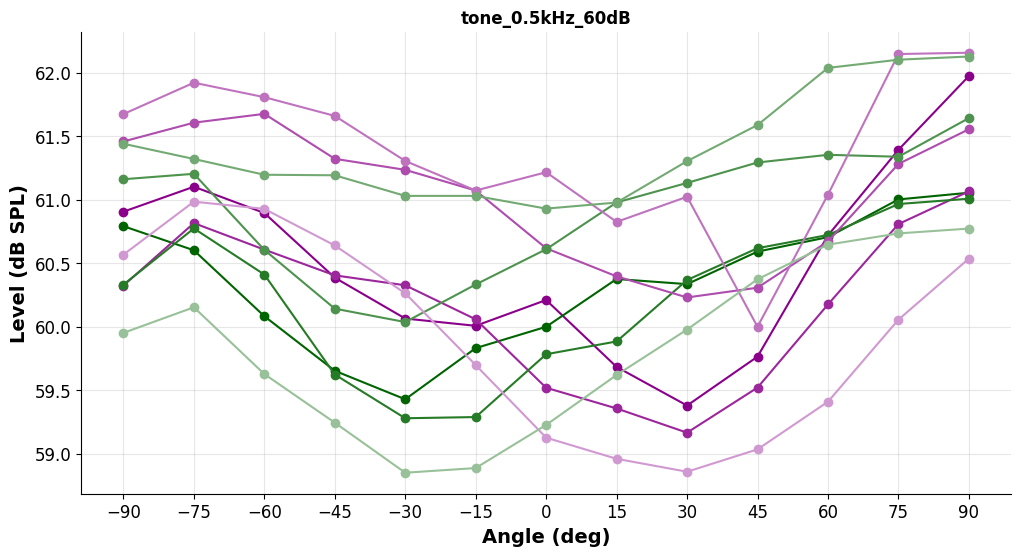

2026-02-10 15:08:46,598 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2026-02-10 15:08:46,707 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=0
2026-02-10 15:08:46,756 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=0
2026-02-10 15:08:46,780 [DEBUG]  [run_hrtf] Starting HRTF for angle=-45 subj=0
2026-02-10 15:08:46,812 [DEBUG]  [run_hrtf] Starting HRTF for angle=-30 subj=0
2026-02-10 15:08:46,822 [DEBUG]  [run_hrtf] Starting HRTF for angle=-15 subj=0
2026-02-10 15:08:46,830 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2026-02-10 15:08:46,844 [DEBUG]  [run_hrtf] Starting HRTF for angle=15 subj=0
2026-02-10 15:08:46,851 [DEBUG]  [run_hrtf] Starting HRTF for angle=30 subj=0
2026-02-10 15:08:46,858 [DEBUG]  [run_hrtf] Starting HRTF for angle=45 subj=0
2026-02-10 15:08:46,867 [DEBUG]  [run_hrtf] Starting HRTF for angle=60 subj=0
2026-02-10 15:08:46,971 [DEBUG]  [run_hrtf] Starting HRTF for angle=75 subj=0
2026-02-10 15:08:46,988 [DEBUG]  [run_hrtf] Starting HRTF f

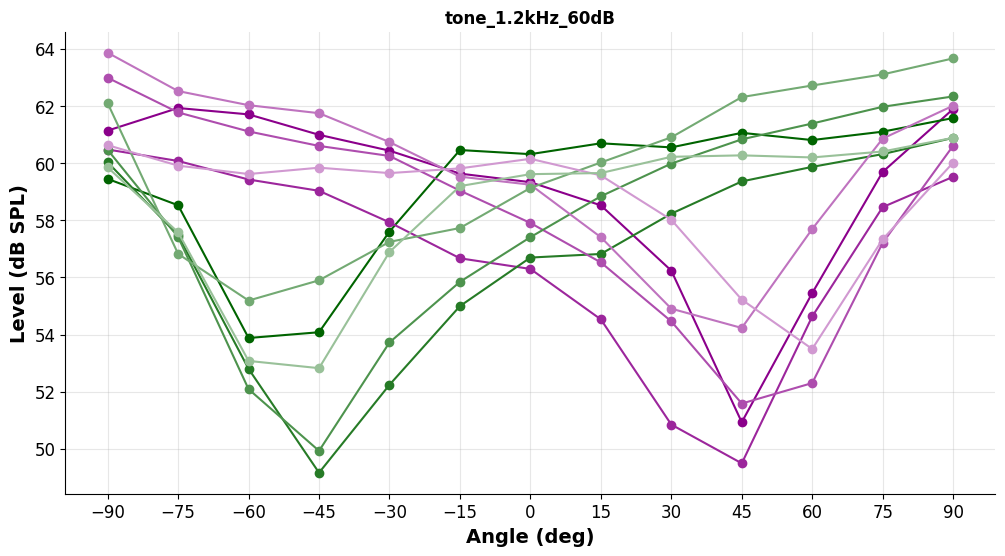

2026-02-10 15:08:49,557 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2026-02-10 15:08:49,796 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=0
2026-02-10 15:08:49,811 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=0
2026-02-10 15:08:49,822 [DEBUG]  [run_hrtf] Starting HRTF for angle=-45 subj=0
2026-02-10 15:08:49,830 [DEBUG]  [run_hrtf] Starting HRTF for angle=-30 subj=0
2026-02-10 15:08:49,836 [DEBUG]  [run_hrtf] Starting HRTF for angle=-15 subj=0
2026-02-10 15:08:49,855 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2026-02-10 15:08:49,895 [DEBUG]  [run_hrtf] Starting HRTF for angle=15 subj=0
2026-02-10 15:08:50,121 [DEBUG]  [run_hrtf] Starting HRTF for angle=30 subj=0
2026-02-10 15:08:50,140 [DEBUG]  [run_hrtf] Starting HRTF for angle=45 subj=0
2026-02-10 15:08:50,159 [DEBUG]  [run_hrtf] Starting HRTF for angle=60 subj=0
2026-02-10 15:08:50,190 [DEBUG]  [run_hrtf] Starting HRTF for angle=75 subj=0
2026-02-10 15:08:50,232 [DEBUG]  [run_hrtf] Starting HRTF f

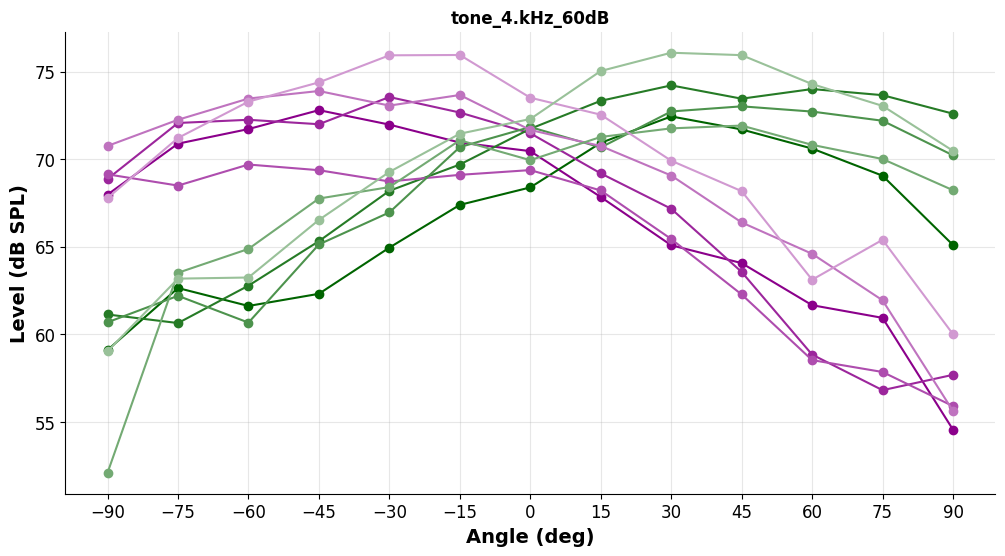

2026-02-10 15:08:52,980 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2026-02-10 15:08:53,086 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=0
2026-02-10 15:08:53,099 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=0
2026-02-10 15:08:53,126 [DEBUG]  [run_hrtf] Starting HRTF for angle=-45 subj=0
2026-02-10 15:08:53,241 [DEBUG]  [run_hrtf] Starting HRTF for angle=-30 subj=0
2026-02-10 15:08:53,320 [DEBUG]  [run_hrtf] Starting HRTF for angle=-15 subj=0
2026-02-10 15:08:53,329 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2026-02-10 15:08:53,338 [DEBUG]  [run_hrtf] Starting HRTF for angle=15 subj=0
2026-02-10 15:08:53,352 [DEBUG]  [run_hrtf] Starting HRTF for angle=30 subj=0
2026-02-10 15:08:53,370 [DEBUG]  [run_hrtf] Starting HRTF for angle=45 subj=0
2026-02-10 15:08:53,558 [DEBUG]  [run_hrtf] Starting HRTF for angle=60 subj=0
2026-02-10 15:08:53,571 [DEBUG]  [run_hrtf] Starting HRTF for angle=75 subj=0
2026-02-10 15:08:53,580 [DEBUG]  [run_hrtf] Starting HRTF f

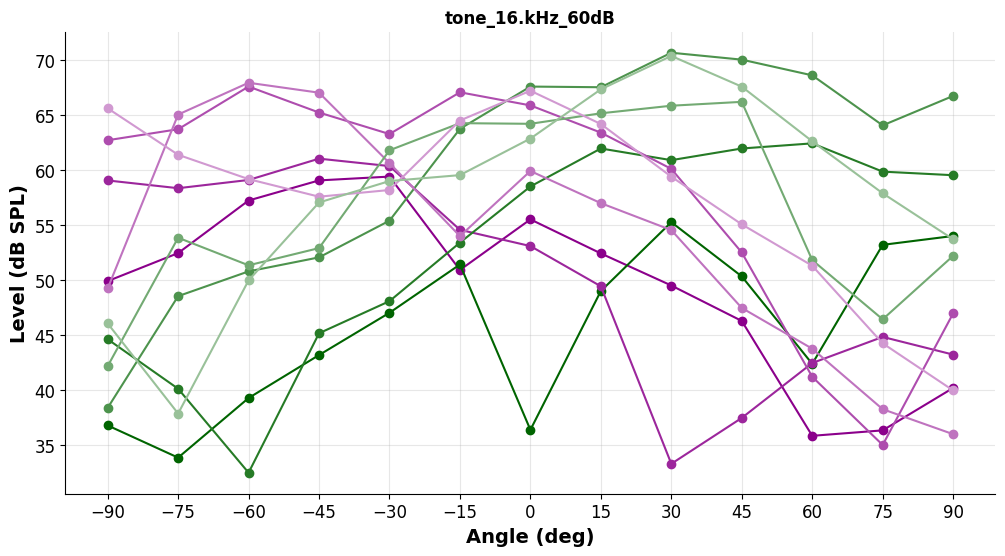

2026-02-10 15:08:56,415 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2026-02-10 15:08:56,549 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=0
2026-02-10 15:08:56,565 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=0
2026-02-10 15:08:56,573 [DEBUG]  [run_hrtf] Starting HRTF for angle=-45 subj=0
2026-02-10 15:08:56,583 [DEBUG]  [run_hrtf] Starting HRTF for angle=-30 subj=0
2026-02-10 15:08:56,590 [DEBUG]  [run_hrtf] Starting HRTF for angle=-15 subj=0
2026-02-10 15:08:56,596 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2026-02-10 15:08:56,601 [DEBUG]  [run_hrtf] Starting HRTF for angle=15 subj=0
2026-02-10 15:08:56,616 [DEBUG]  [run_hrtf] Starting HRTF for angle=30 subj=0
2026-02-10 15:08:56,713 [DEBUG]  [run_hrtf] Starting HRTF for angle=45 subj=0
2026-02-10 15:08:56,802 [DEBUG]  [run_hrtf] Starting HRTF for angle=60 subj=0
2026-02-10 15:08:56,806 [DEBUG]  [run_hrtf] Starting HRTF for angle=75 subj=0
2026-02-10 15:08:56,817 [DEBUG]  [run_hrtf] Starting HRTF f

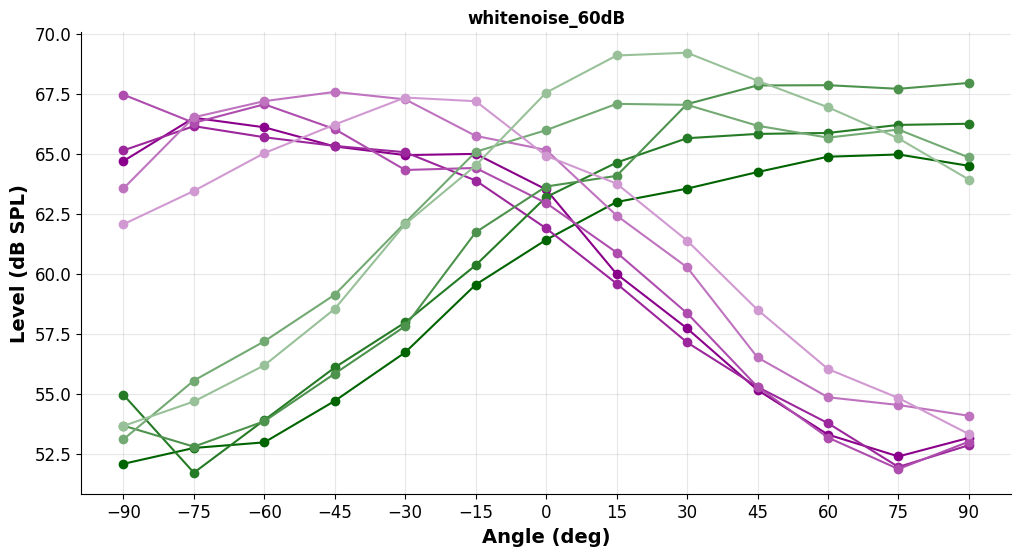

In [37]:
for sound in inputs:
    plt.figure(figsize=(12, 6))
    plt.title(create_sound_key(sound))  # <- only sound name, as requested

    for s_idx, subj in enumerate(subjects):
        p.cochlea[ZI_COC_KEY]['hrtf_params']['subj_number'] = subj

        g_levels = []
        l_levels = []
        r_levels = []

        for angle in ANGLES:
            binaural, g = run_hrtf(sound, angle, p.cochlea[ZI_COC_KEY]['hrtf_params'])
            g_levels.append(g.level)
            l_levels.append(binaural[:, 0].level)
            r_levels.append(binaural[:, 1].level)

        # plot: left = magenta shades, right = green shades
        plt.plot(
            ANGLES, l_levels, "o-",
            color=magenta_colors[s_idx],
        )
        plt.plot(
            ANGLES, r_levels, "o-",
            color=green_colors[s_idx],
        )

    plt.xlabel("Angle (deg)")
    plt.ylabel("Level (dB SPL)")
    plt.grid(True, alpha=0.3)
    plt.xticks(ANGLES)
    # legend: one entry for Left and one for Right is usually enough
    plt.show()


2026-02-10 15:09:01,121 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2026-02-10 15:09:01,217 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=0
2026-02-10 15:09:01,409 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=0
2026-02-10 15:09:01,423 [DEBUG]  [run_hrtf] Starting HRTF for angle=-45 subj=0
2026-02-10 15:09:01,431 [DEBUG]  [run_hrtf] Starting HRTF for angle=-30 subj=0
2026-02-10 15:09:01,438 [DEBUG]  [run_hrtf] Starting HRTF for angle=-15 subj=0
2026-02-10 15:09:01,463 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2026-02-10 15:09:01,547 [DEBUG]  [run_hrtf] Starting HRTF for angle=15 subj=0
2026-02-10 15:09:01,669 [DEBUG]  [run_hrtf] Starting HRTF for angle=30 subj=0
2026-02-10 15:09:01,678 [DEBUG]  [run_hrtf] Starting HRTF for angle=45 subj=0
2026-02-10 15:09:01,690 [DEBUG]  [run_hrtf] Starting HRTF for angle=60 subj=0
2026-02-10 15:09:01,697 [DEBUG]  [run_hrtf] Starting HRTF for angle=75 subj=0
2026-02-10 15:09:01,703 [DEBUG]  [run_hrtf] Starting HRTF f

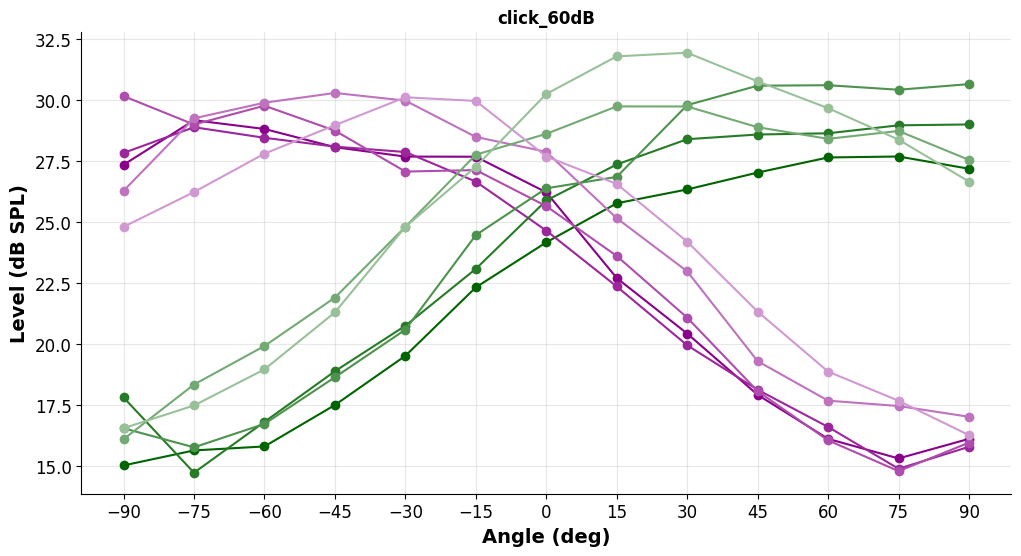

In [38]:
for sound in inputs_2:
    plt.figure(figsize=(12, 6))
    plt.title(create_sound_key(sound))  # <- only sound name, as requested

    for s_idx, subj in enumerate(subjects):
        p.cochlea[ZI_COC_KEY]['hrtf_params']['subj_number'] = subj

        g_levels = []
        l_levels = []
        r_levels = []

        for angle in ANGLES:
            binaural, g = run_hrtf(sound, angle, p.cochlea[ZI_COC_KEY]['hrtf_params'])
            g_levels.append(g.level)
            l_levels.append(binaural[:, 0].level)
            r_levels.append(binaural[:, 1].level)

        # plot: left = magenta shades, right = green shades
        plt.plot(
            ANGLES, l_levels, "o-",
            color=magenta_colors[s_idx],
        )
        plt.plot(
            ANGLES, r_levels, "o-",
            color=green_colors[s_idx],
        )

    plt.xlabel("Angle (deg)")
    plt.ylabel("Level (dB SPL)")
    plt.grid(True, alpha=0.3)
    plt.xticks(ANGLES)
    # legend: one entry for Left and one for Right is usually enough
    plt.show()


2026-02-10 15:20:55,004 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2026-02-10 15:20:55,039 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=1
2026-02-10 15:20:55,046 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=2
2026-02-10 15:20:55,063 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=3
2026-02-10 15:20:55,079 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=4
2026-02-10 15:20:55,097 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=0
2026-02-10 15:20:55,101 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=1
2026-02-10 15:20:55,105 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=2
2026-02-10 15:20:55,109 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=3
2026-02-10 15:20:55,113 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=4
2026-02-10 15:20:55,117 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=0
2026-02-10 15:20:55,121 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=1
2026-02-10 15:20:55,124 [DEBUG]  [run_hrtf] Starting

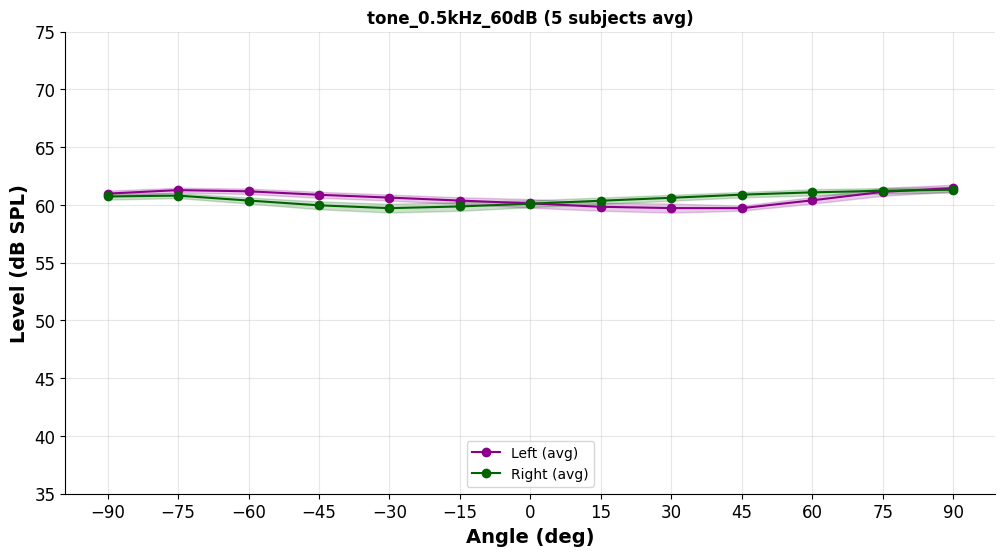

2026-02-10 15:20:55,457 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2026-02-10 15:20:55,474 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=1
2026-02-10 15:20:55,478 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=2
2026-02-10 15:20:55,494 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=3
2026-02-10 15:20:55,510 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=4
2026-02-10 15:20:55,527 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=0
2026-02-10 15:20:55,533 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=1
2026-02-10 15:20:55,538 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=2
2026-02-10 15:20:55,556 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=3
2026-02-10 15:20:55,572 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=4
2026-02-10 15:20:55,590 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=0
2026-02-10 15:20:55,596 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=1
2026-02-10 15:20:55,600 [DEBUG]  [run_hrtf] Starting

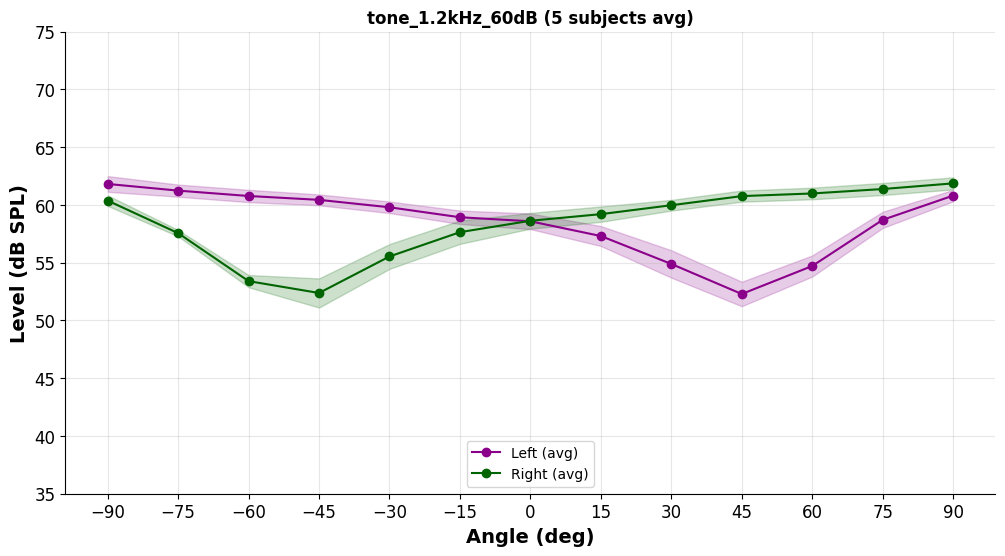

2026-02-10 15:20:55,984 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2026-02-10 15:20:56,004 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=1
2026-02-10 15:20:56,009 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=2
2026-02-10 15:20:56,027 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=3
2026-02-10 15:20:56,045 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=4
2026-02-10 15:20:56,062 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=0
2026-02-10 15:20:56,067 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=1
2026-02-10 15:20:56,071 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=2
2026-02-10 15:20:56,076 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=3
2026-02-10 15:20:56,080 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=4
2026-02-10 15:20:56,086 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=0
2026-02-10 15:20:56,091 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=1
2026-02-10 15:20:56,096 [DEBUG]  [run_hrtf] Starting

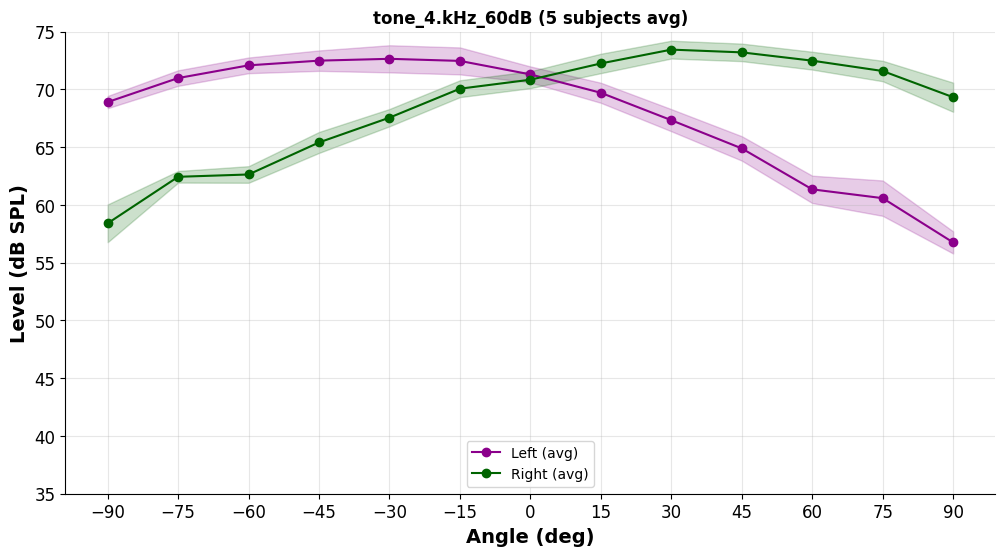

2026-02-10 15:20:56,467 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2026-02-10 15:20:56,484 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=1
2026-02-10 15:20:56,489 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=2
2026-02-10 15:20:56,504 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=3
2026-02-10 15:20:56,519 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=4
2026-02-10 15:20:56,533 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=0
2026-02-10 15:20:56,537 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=1
2026-02-10 15:20:56,541 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=2
2026-02-10 15:20:56,544 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=3
2026-02-10 15:20:56,547 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=4
2026-02-10 15:20:56,551 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=0
2026-02-10 15:20:56,556 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=1
2026-02-10 15:20:56,560 [DEBUG]  [run_hrtf] Starting

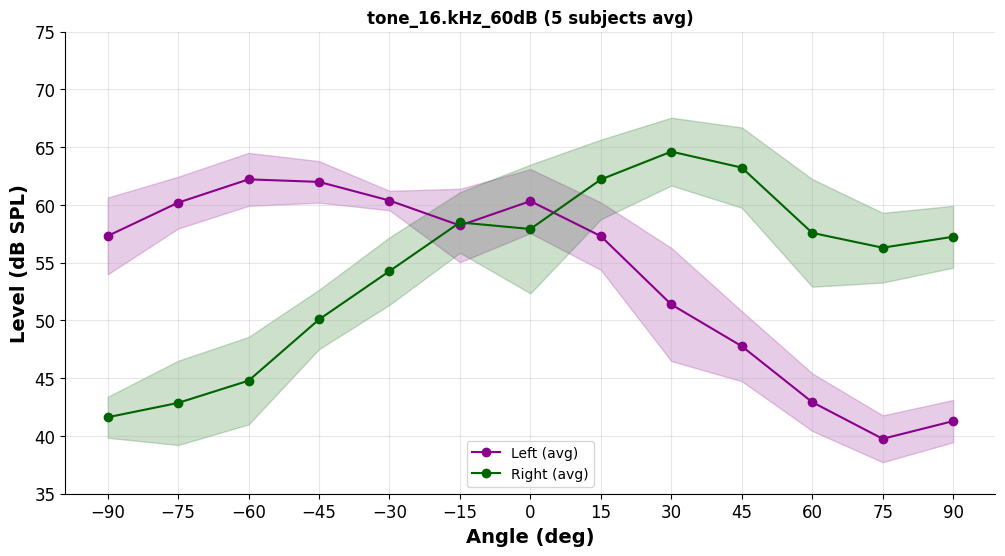

2026-02-10 15:20:56,949 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2026-02-10 15:20:56,968 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=1
2026-02-10 15:20:56,973 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=2
2026-02-10 15:20:56,990 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=3
2026-02-10 15:20:57,008 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=4
2026-02-10 15:20:57,024 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=0
2026-02-10 15:20:57,029 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=1
2026-02-10 15:20:57,034 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=2
2026-02-10 15:20:57,038 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=3
2026-02-10 15:20:57,043 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=4
2026-02-10 15:20:57,048 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=0
2026-02-10 15:20:57,053 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=1
2026-02-10 15:20:57,056 [DEBUG]  [run_hrtf] Starting

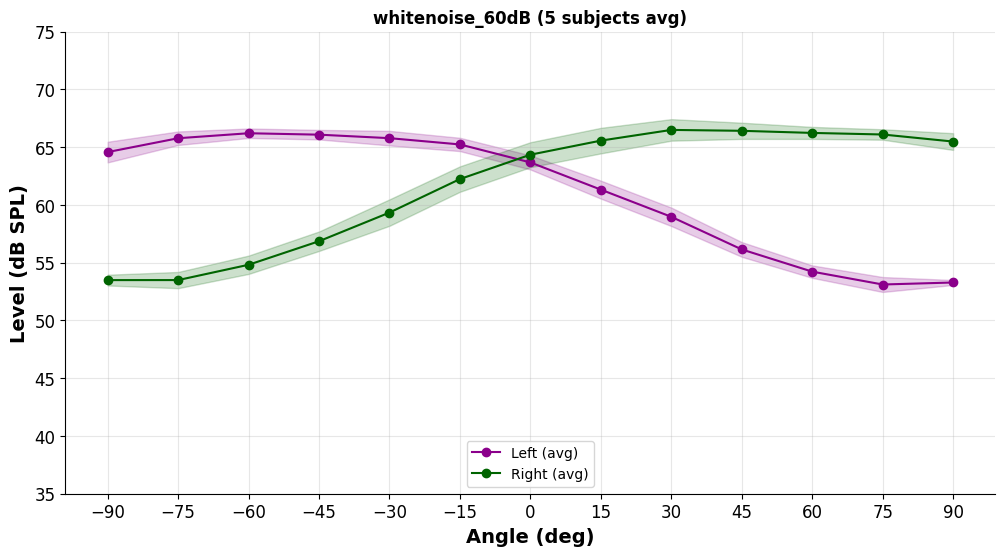

In [40]:
from scipy.stats import sem

for sound in inputs:
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_title(create_sound_key(sound) + f" ({len(subjects)} subjects avg)")


    # --- containers ---
    L_mean_all, R_mean_all = [], []
    L_sem_all,  R_sem_all  = [], []

    for angle in ANGLES:
        L_subj = []
        R_subj = []

        for subj in subjects:
            p.cochlea[ZI_COC_KEY]['hrtf_params']['subj_number'] = subj
            binaural, g = run_hrtf(sound, angle, p.cochlea[ZI_COC_KEY]['hrtf_params'])

            L_subj.append(binaural[:, 0].level)
            R_subj.append(binaural[:, 1].level)

        L_subj = np.array(L_subj)
        R_subj = np.array(R_subj)

        # --- mean ---
        L_mean_all.append(L_subj.mean())
        R_mean_all.append(R_subj.mean())

        # --- SEM ---
        L_sem_all.append(sem(L_subj))
        R_sem_all.append(sem(R_subj))

    # convert to arrays
    L_mean_all = np.array(L_mean_all)
    R_mean_all = np.array(R_mean_all)

    L_sem_all = np.array(L_sem_all)
    R_sem_all = np.array(R_sem_all)

    # --- plotting means ---
    ax.plot(ANGLES, L_mean_all, "o-", color="darkmagenta", label="Left (avg)")
    ax.plot(ANGLES, R_mean_all, "o-", color="darkgreen", label="Right (avg)")

    # --- SEM shading ---
    ax.fill_between(
        ANGLES,
        L_mean_all - L_sem_all,
        L_mean_all + L_sem_all,
        color="darkmagenta",
        alpha=0.2
    )
    ax.fill_between(
        ANGLES,
        R_mean_all - R_sem_all,
        R_mean_all + R_sem_all,
        color="darkgreen",
        alpha=0.2
    )

    # --- cosmetics ---
    ax.set_xlabel("Angle (deg)")
    ax.set_ylabel("Level (dB SPL)")
    #ax.set_ylim([60,100])
    ax.grid(True, alpha=0.3)
    ax.set_xticks(ANGLES)
    ax.legend(loc="lower center")
    ax.set_ylim([35,75])
    plt.show()


2026-02-10 15:29:46,970 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2026-02-10 15:29:47,006 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=1
2026-02-10 15:29:47,013 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=2
2026-02-10 15:29:47,030 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=3
2026-02-10 15:29:47,046 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=4
2026-02-10 15:29:47,062 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=0
2026-02-10 15:29:47,067 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=1
2026-02-10 15:29:47,071 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=2
2026-02-10 15:29:47,075 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=3
2026-02-10 15:29:47,080 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=4
2026-02-10 15:29:47,084 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=0
2026-02-10 15:29:47,088 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=1
2026-02-10 15:29:47,092 [DEBUG]  [run_hrtf] Starting

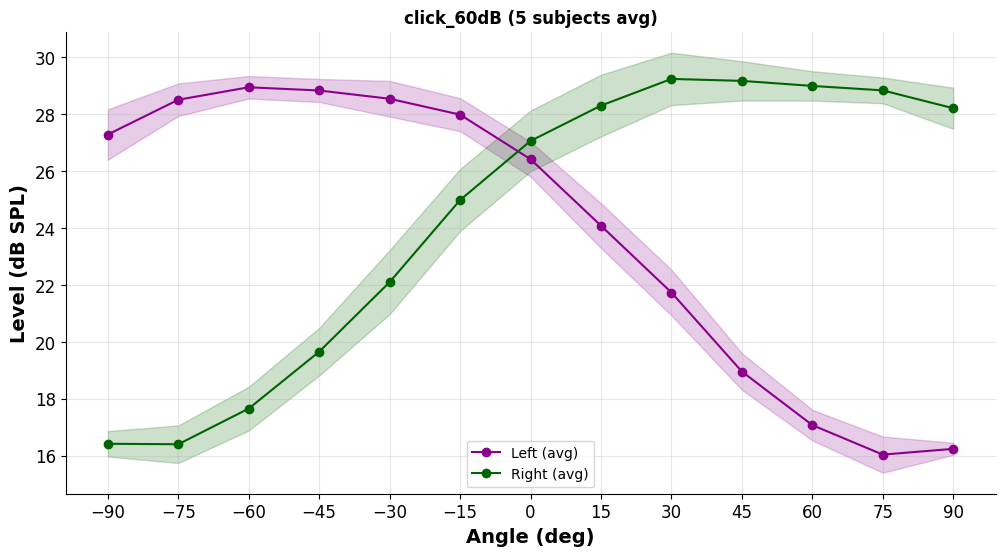

In [41]:
from scipy.stats import sem

for sound in inputs_2:
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_title(create_sound_key(sound) + f" ({len(subjects)} subjects avg)")


    # --- containers ---
    L_mean_all, R_mean_all = [], []
    L_sem_all,  R_sem_all  = [], []

    for angle in ANGLES:
        L_subj = []
        R_subj = []

        for subj in subjects:
            p.cochlea[ZI_COC_KEY]['hrtf_params']['subj_number'] = subj
            binaural, g = run_hrtf(sound, angle, p.cochlea[ZI_COC_KEY]['hrtf_params'])

            L_subj.append(binaural[:, 0].level)
            R_subj.append(binaural[:, 1].level)

        L_subj = np.array(L_subj)
        R_subj = np.array(R_subj)

        # --- mean ---
        L_mean_all.append(L_subj.mean())
        R_mean_all.append(R_subj.mean())

        # --- SEM ---
        L_sem_all.append(sem(L_subj))
        R_sem_all.append(sem(R_subj))

    # convert to arrays
    L_mean_all = np.array(L_mean_all)
    R_mean_all = np.array(R_mean_all)

    L_sem_all = np.array(L_sem_all)
    R_sem_all = np.array(R_sem_all)

    # --- plotting means ---
    ax.plot(ANGLES, L_mean_all, "o-", color="darkmagenta", label="Left (avg)")
    ax.plot(ANGLES, R_mean_all, "o-", color="darkgreen", label="Right (avg)")

    # --- SEM shading ---
    ax.fill_between(
        ANGLES,
        L_mean_all - L_sem_all,
        L_mean_all + L_sem_all,
        color="darkmagenta",
        alpha=0.2
    )
    ax.fill_between(
        ANGLES,
        R_mean_all - R_sem_all,
        R_mean_all + R_sem_all,
        color="darkgreen",
        alpha=0.2
    )

    # --- cosmetics ---
    ax.set_xlabel("Angle (deg)")
    ax.set_ylabel("Level (dB SPL)")
    ax.grid(True, alpha=0.3)
    ax.set_xticks(ANGLES)
    ax.legend(loc="lower center")

    plt.show()


## IACC

In [ ]:
# ============================================================
# Interaural Cross-Correlation Coefficient (IACC) vs azimuth
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import pysofaconventions as sofa
from scipy.signal import correlate
from utils.path_utils import Paths
from utils.cochlea_utils import ANGLE_TO_ARI, ANGLES

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

TARGET_EL = 0                     # degrees

# ------------------------------------------------------------
# Load one SOFA file (single subject)
# ------------------------------------------------------------
files = sorted(
    f for f in os.listdir(Paths.SOFA_DIR)
    if f.lower().endswith(".sofa")
)

sofa_file = sofa.SOFAFile(str(Paths.SOFA_DIR + files[0]), "r")

ir = sofa_file.getDataIR()                      # (M, R, N)
positions = sofa_file.getSourcePositionValues() # (M, C)
az = positions[:, 0]
el = positions[:, 1]

# ------------------------------------------------------------
# IACC computation
# ------------------------------------------------------------
def compute_iacc(left_ir, right_ir):
    """
    Interaural Cross-Correlation Coefficient (IACC):
    max of normalized cross-correlation across all lags
    """
    corr = correlate(left_ir, right_ir, mode='full')

    norm = np.sqrt(np.sum(left_ir**2) * np.sum(right_ir**2))
    corr_norm = corr / norm

    return np.max(np.abs(corr_norm))


iacc_values = []

# ------------------------------------------------------------
# Loop over azimuth angles
# ------------------------------------------------------------
for angle in ANGLES:
    az_conv = ANGLE_TO_ARI[angle]

    # find closest measurement to (angle, 0°)
    dist = np.sqrt((az - az_conv)**2 + (el - TARGET_EL)**2)
    m_idx = int(np.argmin(dist))

    left_ir  = ir[m_idx, 0, :]
    right_ir = ir[m_idx, 1, :]

    iacc = compute_iacc(left_ir, right_ir)
    iacc_values.append(iacc)

iacc_values = np.array(iacc_values)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(ANGLES, iacc_values, marker='o')
ax.axvline(0, color='gray', linestyle='dashed', linewidth=1)

ax.set_xlabel("Azimuth (degrees)")
ax.set_ylabel("IACC")
ax.set_title("Interaural Cross-Correlation Coefficient vs Azimuth")

ax.set_xlim(-90, 90)
ax.set_xticks(ANGLES)
ax.set_ylim(0, 1.05)
ax.grid(True, linestyle=':')

plt.tight_layout()
plt.show()


ImportError: cannot import name 'ANGLE_TO_ARI' from 'utils.cochlea_utils' (/Users/francescodesantis/Documents/repos/sound_localization_model/simulate/utils/cochlea_utils.py)

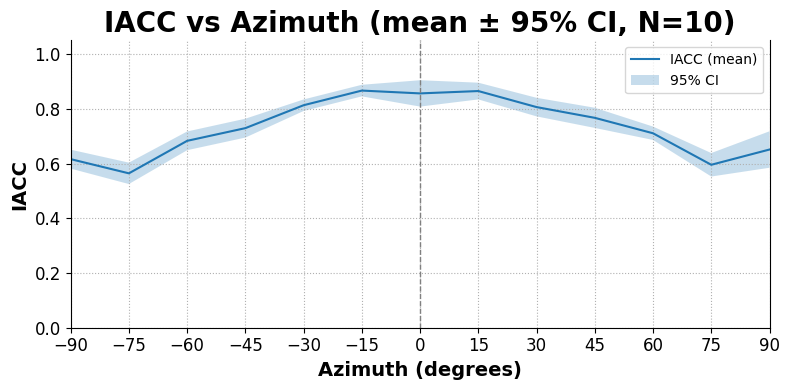

In [ ]:
# ============================================================
# IACC estimation vs azimuth
# Averaged over 10 subjects with 95% CI
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import pysofaconventions as sofa
from scipy.signal import correlate
from utils.path_utils import Paths
from utils.cochlea_utils import ANGLE_TO_ARI, ANGLES

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------
TARGET_EL = 0
N_SUBJ = 10
EPS = 1e-12

# ------------------------------------------------------------
# IACC definition
# ------------------------------------------------------------
def compute_iacc(left_ir, right_ir):
    """
    Interaural Cross-Correlation Coefficient (IACC)
    max |normalized cross-correlation|
    """
    corr = correlate(left_ir, right_ir, mode='full')
    norm = np.sqrt(np.sum(left_ir**2) * np.sum(right_ir**2)) + EPS
    corr_norm = corr / norm
    return np.max(np.abs(corr_norm))


# ------------------------------------------------------------
# Load SOFA files
# ------------------------------------------------------------
files = sorted(
    f for f in os.listdir(Paths.SOFA_DIR)
    if f.lower().endswith(".sofa")
)[:N_SUBJ]

iacc_all = []   # shape: (subjects, angles)

# ------------------------------------------------------------
# Loop over subjects
# ------------------------------------------------------------
for fname in files:
    sofa_file = sofa.SOFAFile(str(Paths.SOFA_DIR + fname), "r")

    ir = sofa_file.getDataIR()
    pos = sofa_file.getSourcePositionValues()
    az = pos[:, 0]
    el = pos[:, 1]

    iacc_subj = []

    for angle in ANGLES:
        az_conv = ANGLE_TO_ARI[angle]
        dist = np.sqrt((az - az_conv)**2 + (el - TARGET_EL)**2)
        m_idx = int(np.argmin(dist))

        L = ir[m_idx, 0, :]
        R = ir[m_idx, 1, :]

        iacc_subj.append(compute_iacc(L, R))

    iacc_all.append(iacc_subj)

iacc_all = np.array(iacc_all)   # (N_SUBJ, N_ANGLES)

# ------------------------------------------------------------
# Mean + 95% CI
# ------------------------------------------------------------
iacc_mean = np.mean(iacc_all, axis=0)
iacc_ci = 1.96 * np.std(iacc_all, axis=0) / np.sqrt(N_SUBJ)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(ANGLES, iacc_mean, label="IACC (mean)")
ax.fill_between(
    ANGLES,
    iacc_mean - iacc_ci,
    iacc_mean + iacc_ci,
    alpha=0.25,
    label="95% CI"
)

ax.axvline(0, color='gray', linestyle='dashed', linewidth=1)

ax.set_xlabel("Azimuth (degrees)")
ax.set_ylabel("IACC")
ax.set_title("IACC vs Azimuth (mean ± 95% CI, N=10)")

ax.set_xlim(-90, 90)
ax.set_ylim(0, 1.05)
ax.set_xticks(ANGLES)
ax.grid(True, linestyle=':')
ax.legend()

plt.tight_layout()
plt.show()


## ITDs

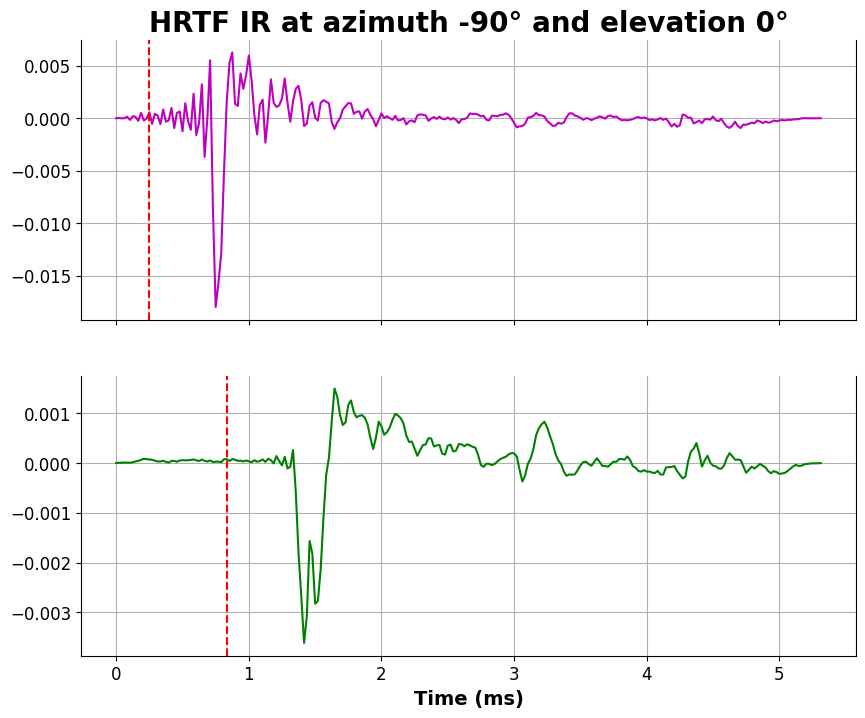

In [ ]:
from utils.cochlea_utils import ANGLE_TO_ARI

fig, ax = plt.subplots(2,1, figsize=(10,8), sharex=True)
times = np.arange(ir.shape[2]) / sofa_fs * 1000  # in ms
a = -90
az_converted = ANGLE_TO_ARI[a]
diff_az = az - az_converted
diff_el = el - 0
dist = np.sqrt(diff_az**2 + diff_el**2)
m_idx = int(np.argmin(dist))
ax[0].plot(times, ir[m_idx, 0, :], color='m')
ax[1].plot(times, ir[m_idx, 1, :], color='g')
ax[0].set_title(f'HRTF IR at azimuth {a}° and elevation 0°')
ax[1].set_xlabel("Time (ms)")

t_L = onset_time(ir[m_idx, 0, :])
t_R = onset_time(ir[m_idx, 1, :])
ax[0] .axvline(t_L * 1000, color='r', linestyle='dashed', label='Onset Left')
ax[1] .axvline(t_R * 1000, color='r', linestyle='dashed', label='Onset Right')


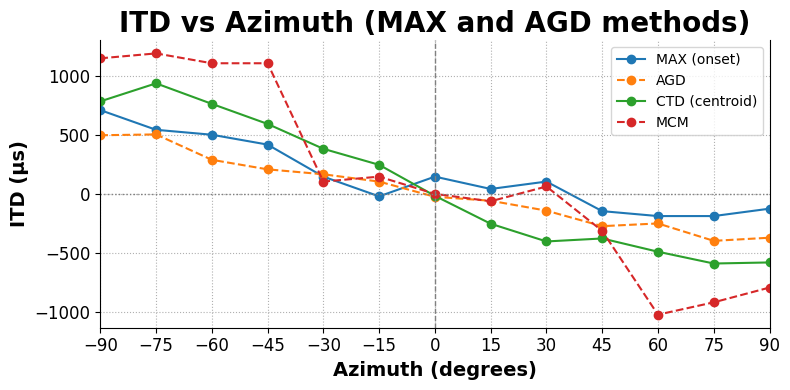

In [ ]:
# ============================================================
# ITD estimation using MAX and AGD methods
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import pysofaconventions as sofa
from scipy.signal import hilbert
from scipy.fft import rfft
from utils.path_utils import Paths
from utils.cochlea_utils import ANGLE_TO_ARI, ANGLES

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------  # degrees
TARGET_EL = 0                     # degrees
ONSET_DB = -30                    # threshold for MAX (dB relative to peak)
EPS = 1e-12
subj = 2
# ------------------------------------------------------------
# Load one SOFA subject
# ------------------------------------------------------------
files = sorted(
    f for f in os.listdir(Paths.SOFA_DIR)
    if f.lower().endswith(".sofa")
)

sofa_file = sofa.SOFAFile(str(Paths.SOFA_DIR + files[subj]), "r")

ir = sofa_file.getDataIR()                      # (M, R, N)
positions = sofa_file.getSourcePositionValues()
az = positions[:, 0]
el = positions[:, 1]

fs = float(np.array(sofa_file.getSamplingRate()).ravel()[0])

# ------------------------------------------------------------
# MAX method: ITD from first onset (30 dB below peak)
# ------------------------------------------------------------
def itd_max(left_ir, right_ir, fs, onset_db=-30):
    def onset_time(ir):
        env = np.abs(hilbert(ir))
        peak = np.max(env)
        threshold = peak * 10**(onset_db / 20)
        idx = np.where(env >= threshold)[0][0]
        return idx / fs

    t_L = onset_time(left_ir)
    t_R = onset_time(right_ir)

    return t_R - t_L   # ITD (s), positive = right ear later


# ------------------------------------------------------------
# AGD method: average interaural group delay
# ------------------------------------------------------------
def itd_agd(left_ir, right_ir, fs):
    L_fft = rfft(left_ir)
    R_fft = rfft(right_ir)

    # Interaural phase difference
    IPD = np.unwrap(np.angle(R_fft) - np.angle(L_fft))

    freqs = np.fft.rfftfreq(len(left_ir), d=1/fs)

    # Avoid DC
    valid = freqs > 0

    # Group delay = -dφ/df / (2π)
    dphi = np.gradient(IPD[valid], freqs[valid])
    gd = -dphi / (2 * np.pi)

    # Spectral average (AGD)
    return np.mean(gd)


# ------------------------------------------------------------
# CTD: centroid time delay
# ------------------------------------------------------------
def itd_ctd(left_ir, right_ir, fs):
    def centroid_time(ir):
        env = np.abs(hilbert(ir))
        t = np.arange(len(ir)) / fs
        return np.sum(t * env) / (np.sum(env) + EPS)

    t_L = centroid_time(left_ir)
    t_R = centroid_time(right_ir)

    return t_R - t_L   # seconds


# ------------------------------------------------------------
# MCM: minimum-phase coherence method
# ------------------------------------------------------------
def minimum_phase_ir(ir):
    """
    Compute minimum-phase version of an IR via real cepstrum
    """
    IR_fft = rfft(ir)
    log_mag = np.log(np.abs(IR_fft) + EPS)

    cepstrum = irfft(log_mag)

    cep_min = np.zeros_like(cepstrum)
    cep_min[0] = cepstrum[0]
    cep_min[1:len(cepstrum)//2] = 2 * cepstrum[1:len(cepstrum)//2]

    min_phase_fft = np.exp(rfft(cep_min))
    return irfft(min_phase_fft)


def itd_mcm(left_ir, right_ir, fs):
    # minimum-phase versions
    left_min  = minimum_phase_ir(left_ir)
    right_min = minimum_phase_ir(right_ir)

    # coherence function peak ≈ max cross-correlation
    corr = correlate(left_ir, left_min, mode='full')
    lag_L = np.argmax(corr) - (len(left_ir) - 1)

    corr = correlate(right_ir, right_min, mode='full')
    lag_R = np.argmax(corr) - (len(right_ir) - 1)

    return (lag_R - lag_L) / fs   # seconds

# ------------------------------------------------------------
# Loop over azimuth angles
# ------------------------------------------------------------
itd_max_vals = []
itd_agd_vals = []
itd_ctd_vals = []
itd_mcm_vals = []

for angle in ANGLES:
    az_conv = ANGLE_TO_ARI[angle]

    dist = np.sqrt((az - az_conv)**2 + (el - TARGET_EL)**2)
    m_idx = int(np.argmin(dist))

    left_ir  = ir[m_idx, 0, :]
    right_ir = ir[m_idx, 1, :]

    itd_max_vals.append(itd_max(left_ir, right_ir, fs))
    itd_agd_vals.append(itd_agd(left_ir, right_ir, fs))
    itd_ctd_vals.append(itd_ctd(left_ir, right_ir, fs))
    itd_mcm_vals.append(itd_mcm(left_ir, right_ir, fs))

itd_ctd_vals = np.array(itd_ctd_vals) * 1e6   # → µs
itd_mcm_vals = np.array(itd_mcm_vals) * 1e6   # → µs
itd_max_vals = np.array(itd_max_vals) * 1e6   # → µs
itd_agd_vals = np.array(itd_agd_vals) * 1e6   # → µs

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(ANGLES, itd_max_vals, 'o-', label='MAX (onset)')
ax.plot(ANGLES, itd_agd_vals, 'o--', label='AGD')
ax.plot(ANGLES, itd_ctd_vals, 'o-', label='CTD (centroid)')
ax.plot(ANGLES, itd_mcm_vals, 'o--', label='MCM')

ax.axvline(0, color='gray', linestyle='dashed', linewidth=1)
ax.axhline(0, color='gray', linestyle='dotted', linewidth=1)

ax.set_xlabel("Azimuth (degrees)")
ax.set_ylabel("ITD (µs)")
ax.set_title("ITD vs Azimuth (MAX and AGD methods)")

ax.set_xlim(-90, 90)
ax.set_xticks(ANGLES)
ax.grid(True, linestyle=':')

ax.legend()
plt.tight_layout()
plt.show()


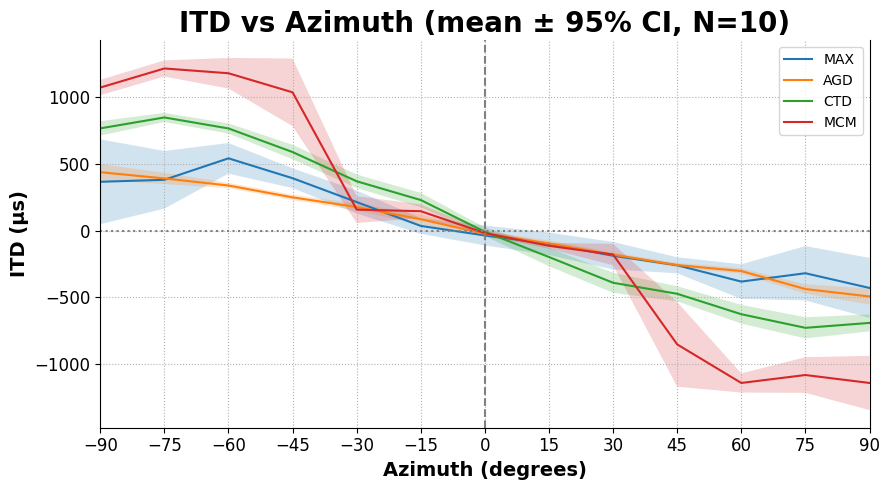

In [ ]:
# ============================================================
# ITD estimation using MAX, AGD, CTD, MCM
# Averaged over 10 subjects with 95% CI
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import pysofaconventions as sofa
from scipy.signal import hilbert, correlate
from scipy.fft import rfft, irfft
from utils.path_utils import Paths
from utils.cochlea_utils import ANGLE_TO_ARI, ANGLES

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------
TARGET_EL = 0
ONSET_DB = -30
EPS = 1e-12
N_SUBJ = 10

# ------------------------------------------------------------
# ITD METHODS
# ------------------------------------------------------------
def itd_max(left_ir, right_ir, fs, onset_db=-30):
    def onset_time(ir):
        env = np.abs(hilbert(ir))
        threshold = np.max(env) * 10**(onset_db / 20)
        idx = np.where(env >= threshold)[0][0]
        return idx / fs
    return onset_time(right_ir) - onset_time(left_ir)


def itd_agd(left_ir, right_ir, fs):
    L_fft = rfft(left_ir)
    R_fft = rfft(right_ir)
    IPD = np.unwrap(np.angle(R_fft) - np.angle(L_fft))
    freqs = np.fft.rfftfreq(len(left_ir), d=1/fs)
    valid = freqs > 0
    gd = -np.gradient(IPD[valid], freqs[valid]) / (2 * np.pi)
    return np.mean(gd)


def itd_ctd(left_ir, right_ir, fs):
    def centroid(ir):
        env = np.abs(hilbert(ir))
        t = np.arange(len(ir)) / fs
        return np.sum(t * env) / (np.sum(env) + EPS)
    return centroid(right_ir) - centroid(left_ir)


def minimum_phase_ir(ir):
    IR_fft = rfft(ir)
    log_mag = np.log(np.abs(IR_fft) + EPS)
    cep = irfft(log_mag)
    cep_min = np.zeros_like(cep)
    cep_min[0] = cep[0]
    cep_min[1:len(cep)//2] = 2 * cep[1:len(cep)//2]
    return irfft(np.exp(rfft(cep_min)))


def itd_mcm(left_ir, right_ir, fs):
    Lmin = minimum_phase_ir(left_ir)
    Rmin = minimum_phase_ir(right_ir)
    lag_L = np.argmax(correlate(left_ir, Lmin, mode='full')) - (len(left_ir) - 1)
    lag_R = np.argmax(correlate(right_ir, Rmin, mode='full')) - (len(right_ir) - 1)
    return (lag_R - lag_L) / fs


# ------------------------------------------------------------
# Load SOFA files
# ------------------------------------------------------------
files = sorted(
    f for f in os.listdir(Paths.SOFA_DIR)
    if f.lower().endswith(".sofa")
)[:N_SUBJ]

# containers: [subjects, angles]
itd_max_all = []
itd_agd_all = []
itd_ctd_all = []
itd_mcm_all = []

# ------------------------------------------------------------
# Loop over subjects
# ------------------------------------------------------------
for fname in files:
    sofa_file = sofa.SOFAFile(str(Paths.SOFA_DIR + fname), "r")
    ir = sofa_file.getDataIR()
    pos = sofa_file.getSourcePositionValues()
    az = pos[:, 0]
    el = pos[:, 1]
    fs = float(np.array(sofa_file.getSamplingRate()).ravel()[0])

    max_s, agd_s, ctd_s, mcm_s = [], [], [], []

    for angle in ANGLES:
        az_conv = ANGLE_TO_ARI[angle]
        dist = np.sqrt((az - az_conv)**2 + (el - TARGET_EL)**2)
        m_idx = int(np.argmin(dist))

        L = ir[m_idx, 0, :]
        R = ir[m_idx, 1, :]

        max_s.append(itd_max(L, R, fs))
        agd_s.append(itd_agd(L, R, fs))
        ctd_s.append(itd_ctd(L, R, fs))
        mcm_s.append(itd_mcm(L, R, fs))

    itd_max_all.append(max_s)
    itd_agd_all.append(agd_s)
    itd_ctd_all.append(ctd_s)
    itd_mcm_all.append(mcm_s)

# convert to µs
itd_max_all = np.array(itd_max_all) * 1e6
itd_agd_all = np.array(itd_agd_all) * 1e6
itd_ctd_all = np.array(itd_ctd_all) * 1e6
itd_mcm_all = np.array(itd_mcm_all) * 1e6

# ------------------------------------------------------------
# Mean + 95% CI
# ------------------------------------------------------------
def mean_ci(x):
    mean = np.mean(x, axis=0)
    ci = 1.96 * np.std(x, axis=0) / np.sqrt(x.shape[0])
    return mean, ci

max_m, max_ci = mean_ci(itd_max_all)
agd_m, agd_ci = mean_ci(itd_agd_all)
ctd_m, ctd_ci = mean_ci(itd_ctd_all)
mcm_m, mcm_ci = mean_ci(itd_mcm_all)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(ANGLES, max_m, label="MAX")
ax.fill_between(ANGLES, max_m - max_ci, max_m + max_ci, alpha=0.2)

ax.plot(ANGLES, agd_m, label="AGD")
ax.fill_between(ANGLES, agd_m - agd_ci, agd_m + agd_ci, alpha=0.2)

ax.plot(ANGLES, ctd_m, label="CTD")
ax.fill_between(ANGLES, ctd_m - ctd_ci, ctd_m + ctd_ci, alpha=0.2)

ax.plot(ANGLES, mcm_m, label="MCM")
ax.fill_between(ANGLES, mcm_m - mcm_ci, mcm_m + mcm_ci, alpha=0.2)

ax.axvline(0, color='gray', linestyle='dashed')
ax.axhline(0, color='gray', linestyle='dotted')

ax.set_xlabel("Azimuth (degrees)")
ax.set_ylabel("ITD (µs)")
ax.set_title("ITD vs Azimuth (mean ± 95% CI, N=10)")

ax.set_xlim(-90, 90)
ax.set_xticks(ANGLES)
ax.grid(True, linestyle=':')
ax.legend()

plt.tight_layout()
plt.show()
